# Análisis de Series de Tiempo: Predicción del Precio de Bitcoin con ARIMA

**Integrantes:** Laura Cardona, Elián Martinez, Tulio Oroco y Luis Pino

**Objetivo:** Modelar y predecir el precio de cierre de Bitcoin (BTC-USD) utilizando modelos ARIMA con diferentes criterios de selección (AIC, BIC, HQIC) y diferentes horizontes de predicción (7, 14, 21 y 28 días), comparando métodos rolling y estático.

---

## 0. Instalación y carga de librerías

In [25]:
# Instalar dependencias si es necesario
# !pip install yfinance==0.2.54 "pandas==2.2.3" statsmodels scipy matplotlib seaborn scikit-learn

In [26]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

import yfinance as yf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.seasonal import seasonal_decompose

from scipy import stats
from scipy.stats import shapiro, kstest, jarque_bera, normaltest

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import itertools

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 12
sns.set_theme(style='whitegrid')

print('Librerías cargadas correctamente.')
print(f'pandas: {pd.__version__}')
print(f'yfinance: {yf.__version__}')

Librerías cargadas correctamente.
pandas: 2.2.3
yfinance: 1.2.0


---
## 1. Descarga y exploración de datos

Se obtienen los datos históricos de Bitcoin (BTC-USD) desde Yahoo Finance, desde el inicio de su cotización hasta la fecha actual.

In [27]:
# 1.1 Descarga de datos
btc_raw = yf.download('BTC-USD', start='2010-01-01', end='2026-03-20', progress=True)

# Aplanar MultiIndex de columnas
btc_raw.columns = btc_raw.columns.get_level_values(0)
btc_raw.index = pd.to_datetime(btc_raw.index)
btc_raw = btc_raw.dropna()

print(f'Rango de fechas: {btc_raw.index.min().date()} → {btc_raw.index.max().date()}')
print(f'Total de observaciones: {len(btc_raw)}')
print(f'\nColumnas disponibles: {btc_raw.columns.tolist()}')
btc_raw.head()

[*********************100%***********************]  1 of 1 completed

Rango de fechas: 2014-09-17 → 2026-03-19
Total de observaciones: 4202

Columnas disponibles: ['Close', 'High', 'Low', 'Open', 'Volume']


Price,Close,High,Low,Open,Volume
Date,,,,,
2014-09-17,457.334015,468.174011,452.421997,465.864014,21056800
2014-09-18,424.440002,456.859985,413.104004,456.859985,34483200
2014-09-19,394.795990,427.834991,384.532013,424.102997,37919700
2014-09-20,408.903992,423.295990,389.882996,394.673004,36863600
2014-09-21,398.821014,412.425995,393.181000,408.084991,26580100


In [28]:
# 1.2 Estadísticas descriptivas
print('=== Estadísticas Descriptivas del Precio de Cierre (USD) ===')
print(btc_raw['Close'].describe().round(2))

=== Estadísticas Descriptivas del Precio de Cierre (USD) ===
count      4202.00
mean      27792.87
std       32133.16
min         178.10
25%        2908.84
50%       11197.25
75%       43707.55
max      124752.53
Name: Close, dtype: float64


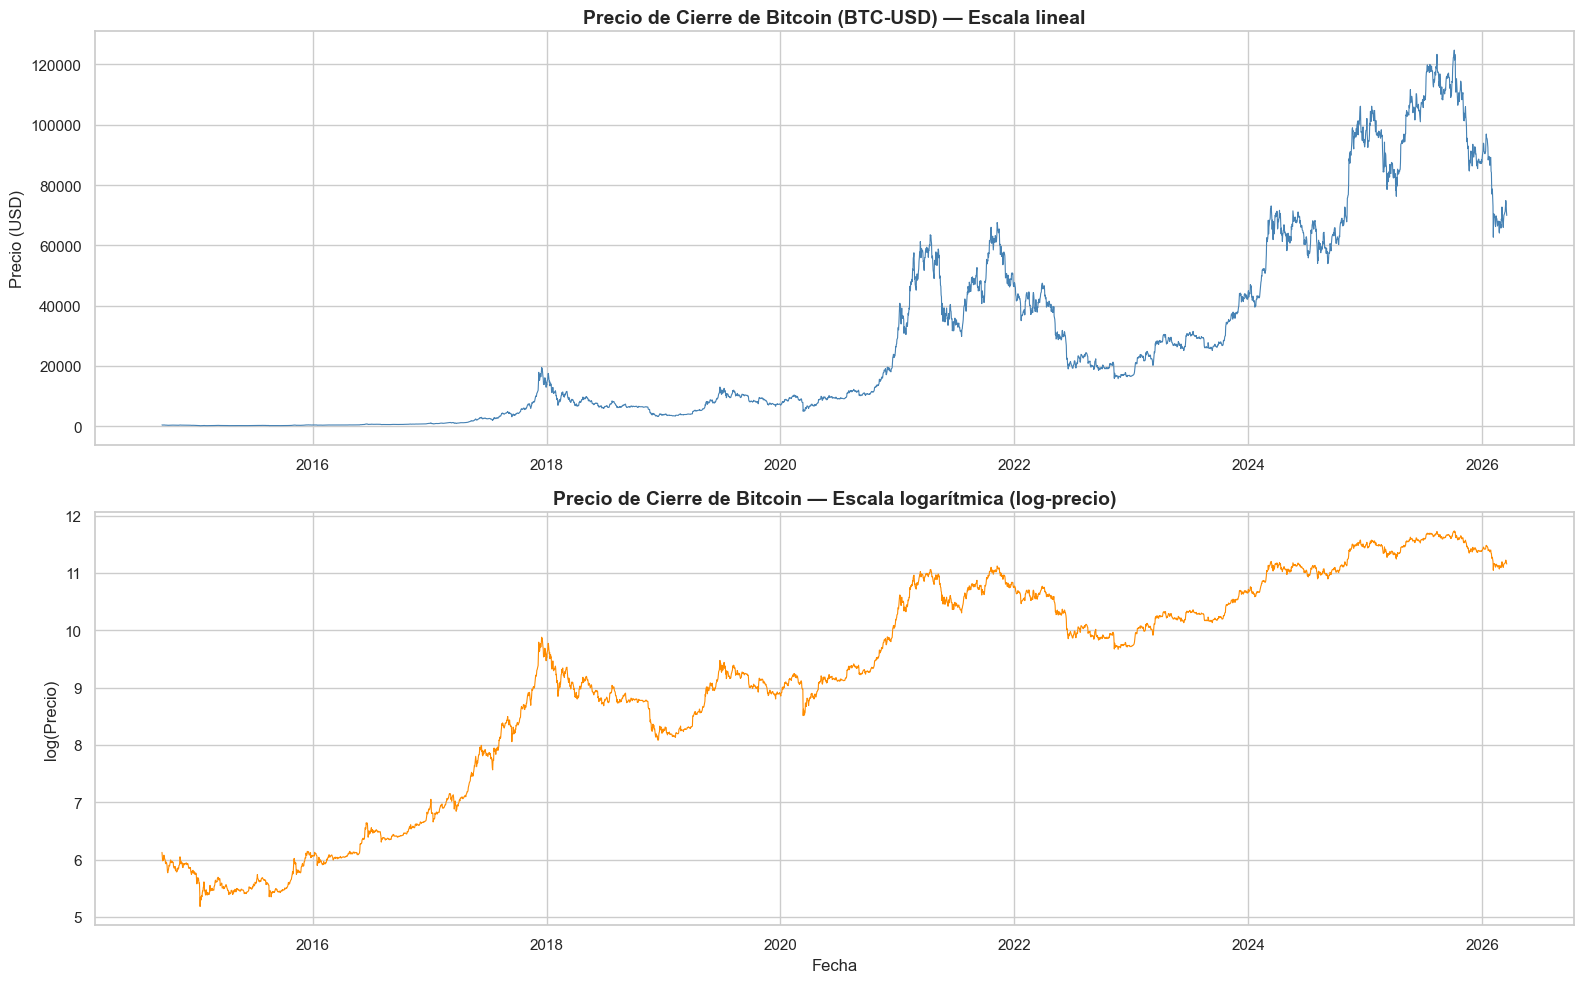


[FIGURA 1] La serie en escala lineal muestra alta asimetría y volatilidad creciente, característica de activos financieros. La transformación logarítmica estabiliza la varianza y es estándar en el análisis de precios financieros.


In [29]:
# 1.3 Serie de tiempo completa
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

axes[0].plot(btc_raw.index, btc_raw['Close'], color='steelblue', linewidth=0.8)
axes[0].set_title('Precio de Cierre de Bitcoin (BTC-USD) — Escala lineal', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Precio (USD)')
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

axes[1].plot(btc_raw.index, np.log(btc_raw['Close']), color='darkorange', linewidth=0.8)
axes[1].set_title('Precio de Cierre de Bitcoin — Escala logarítmica (log-precio)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('log(Precio)')
axes[1].set_xlabel('Fecha')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.savefig('fig_01_serie_completa.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n[FIGURA 1] La serie en escala lineal muestra alta asimetría y volatilidad creciente,'
      ' característica de activos financieros. La transformación logarítmica estabiliza la varianza'
      ' y es estándar en el análisis de precios financieros.')

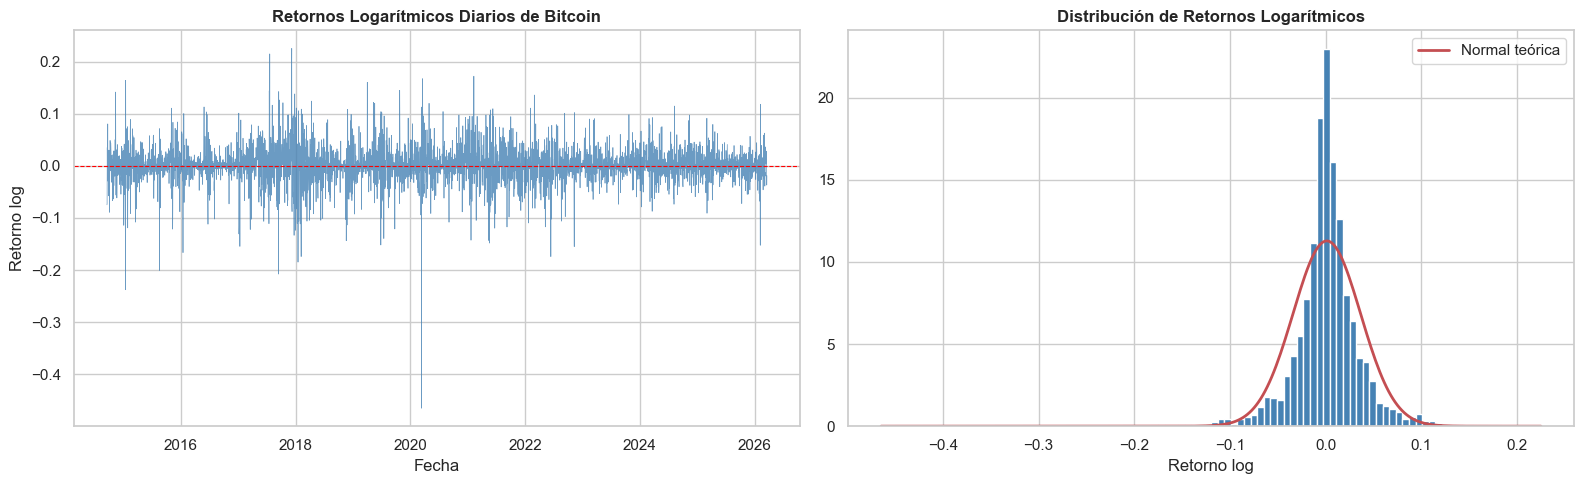

Asimetría (skewness): -0.7091
Curtosis (exceso): 11.7232

[FIGURA 2] Los retornos exhiben colas pesadas (leptocurtosis, curtosis > 3) y leve asimetría negativa, lo que es incompatible con una distribución normal. Esto es típico en criptomonedas.


In [30]:
# 1.4 Retornos logarítmicos diarios
btc_raw['log_return'] = np.log(btc_raw['Close'] / btc_raw['Close'].shift(1))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(btc_raw.index, btc_raw['log_return'], color='steelblue', linewidth=0.5, alpha=0.8)
axes[0].set_title('Retornos Logarítmicos Diarios de Bitcoin', fontweight='bold')
axes[0].set_ylabel('Retorno log')
axes[0].set_xlabel('Fecha')
axes[0].axhline(0, color='red', linewidth=0.8, linestyle='--')

axes[1].hist(btc_raw['log_return'].dropna(), bins=100, color='steelblue', edgecolor='white', density=True)
x = np.linspace(btc_raw['log_return'].dropna().min(), btc_raw['log_return'].dropna().max(), 300)
mu, sigma = btc_raw['log_return'].dropna().mean(), btc_raw['log_return'].dropna().std()
axes[1].plot(x, stats.norm.pdf(x, mu, sigma), 'r-', lw=2, label='Normal teórica')
axes[1].set_title('Distribución de Retornos Logarítmicos', fontweight='bold')
axes[1].set_xlabel('Retorno log')
axes[1].legend()

plt.tight_layout()
plt.savefig('fig_02_retornos.png', dpi=150, bbox_inches='tight')
plt.show()

skew = btc_raw['log_return'].dropna().skew()
kurt = btc_raw['log_return'].dropna().kurt()
print(f'Asimetría (skewness): {skew:.4f}')
print(f'Curtosis (exceso): {kurt:.4f}')
print('\n[FIGURA 2] Los retornos exhiben colas pesadas (leptocurtosis, curtosis > 3) y leve asimetría'
      ' negativa, lo que es incompatible con una distribución normal. Esto es típico en criptomonedas.')

---
## 2. Análisis de Estacionariedad

Para aplicar ARIMA, la serie debe ser estacionaria en covarianza. Se aplican las pruebas ADF y KPSS tanto al precio original como a sus diferencias.

In [31]:
# Usar log del precio para estabilizar varianza
df = btc_raw[['Close']].copy()
df['log_close'] = np.log(df['Close'])
df['diff1'] = df['log_close'].diff(1)
df = df.dropna()

def test_estacionariedad(serie, nombre):
    """Prueba ADF y KPSS y retorna DataFrame con resultados."""
    # ADF
    adf_res = adfuller(serie.dropna(), autolag='AIC')
    # KPSS
    kpss_res = kpss(serie.dropna(), regression='c', nlags='auto')
    
    resultados = {
        'Serie': nombre,
        'ADF Estadístico': round(adf_res[0], 4),
        'ADF p-valor': round(adf_res[1], 4),
        'ADF Conclusión': 'Estacionaria ✅' if adf_res[1] < 0.05 else 'No estacionaria ❌',
        'KPSS Estadístico': round(kpss_res[0], 4),
        'KPSS p-valor': round(kpss_res[1], 4),
        'KPSS Conclusión': 'Estacionaria ✅' if kpss_res[1] > 0.05 else 'No estacionaria ❌'
    }
    return resultados

res1 = test_estacionariedad(df['log_close'], 'log(Precio)')
res2 = test_estacionariedad(df['diff1'], 'Δlog(Precio) — 1ª diferencia')

tabla_est = pd.DataFrame([res1, res2]).set_index('Serie')
print('=== Pruebas de Estacionariedad ===')
print(tabla_est.to_string())
print('\n[TABLA 1] La prueba ADF tiene H₀: la serie tiene raíz unitaria (no estacionaria).')
print('La prueba KPSS tiene H₀: la serie es estacionaria.')
print('Ambas pruebas coinciden: log(Precio) NO es estacionaria; su primera diferencia SÍ lo es.')
print('Por tanto, se requiere d=1 en el modelo ARIMA.')

=== Pruebas de Estacionariedad ===
                              ADF Estadístico  ADF p-valor     ADF Conclusión  KPSS Estadístico  KPSS p-valor    KPSS Conclusión
Serie                                                                                                                           
log(Precio)                           -1.2754       0.6403  No estacionaria ❌            9.1364          0.01  No estacionaria ❌
Δlog(Precio) — 1ª diferencia         -19.7253       0.0000     Estacionaria ✅            0.1397          0.10     Estacionaria ✅

[TABLA 1] La prueba ADF tiene H₀: la serie tiene raíz unitaria (no estacionaria).
La prueba KPSS tiene H₀: la serie es estacionaria.
Ambas pruebas coinciden: log(Precio) NO es estacionaria; su primera diferencia SÍ lo es.
Por tanto, se requiere d=1 en el modelo ARIMA.


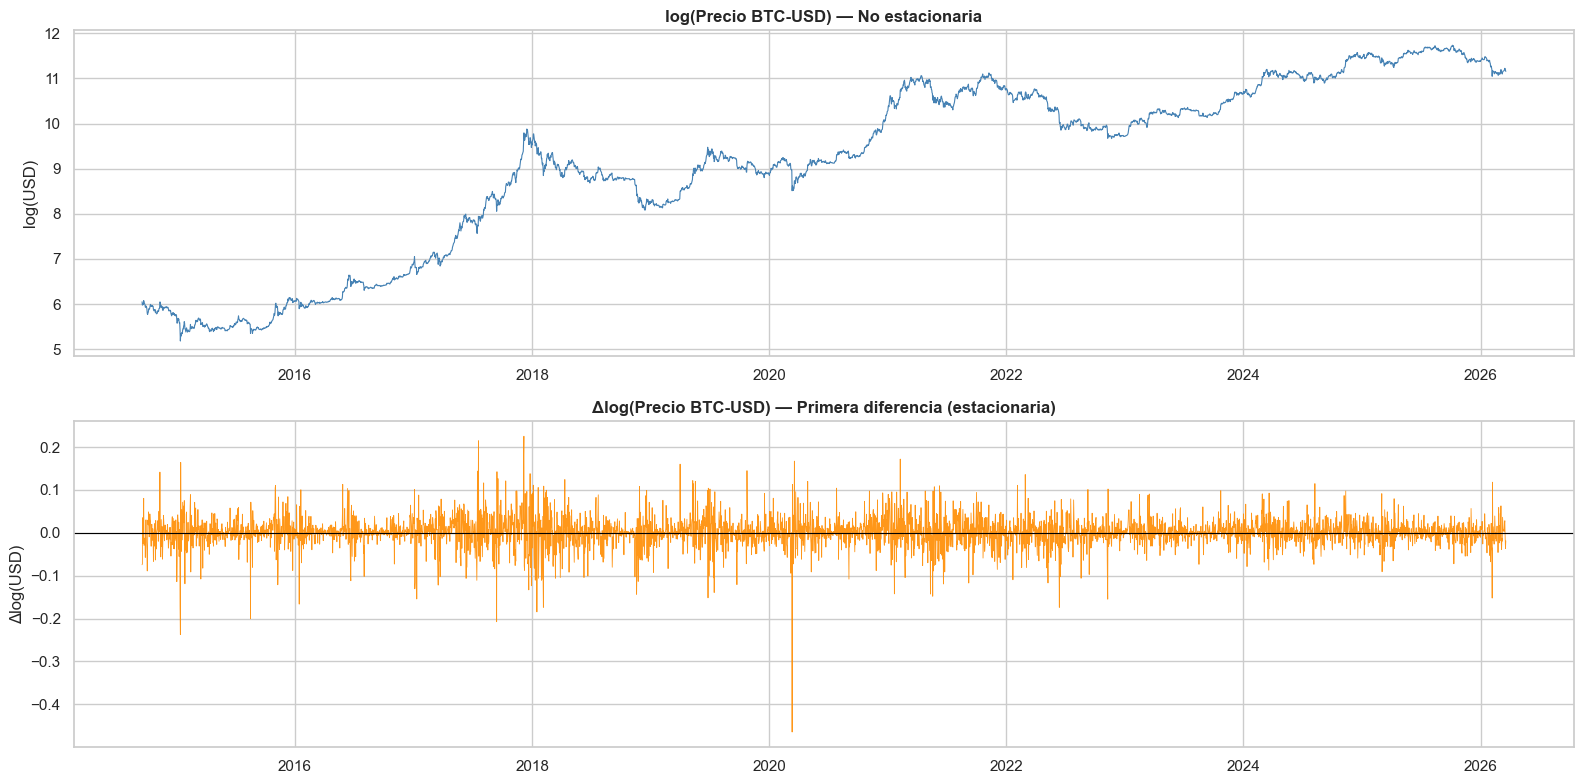

[FIGURA 3] Visualmente se confirma que la primera diferencia del log-precio oscila alrededor de cero sin tendencia aparente, coherente con los resultados de las pruebas formales.


In [32]:
# Visualización de la serie diferenciada
fig, axes = plt.subplots(2, 1, figsize=(16, 8))
axes[0].plot(df.index, df['log_close'], color='steelblue', linewidth=0.8)
axes[0].set_title('log(Precio BTC-USD) — No estacionaria', fontweight='bold')
axes[0].set_ylabel('log(USD)')

axes[1].plot(df.index, df['diff1'], color='darkorange', linewidth=0.6, alpha=0.9)
axes[1].set_title('Δlog(Precio BTC-USD) — Primera diferencia (estacionaria)', fontweight='bold')
axes[1].set_ylabel('Δlog(USD)')
axes[1].axhline(0, color='black', linewidth=0.8)

plt.tight_layout()
plt.savefig('fig_03_estacionariedad.png', dpi=150, bbox_inches='tight')
plt.show()
print('[FIGURA 3] Visualmente se confirma que la primera diferencia del log-precio oscila'
      ' alrededor de cero sin tendencia aparente, coherente con los resultados de las pruebas formales.')

---
## 3. Identificación del orden ARIMA — ACF y PACF

Se analizan los correlogramas de la serie diferenciada para identificar los órdenes p (AR) y q (MA).

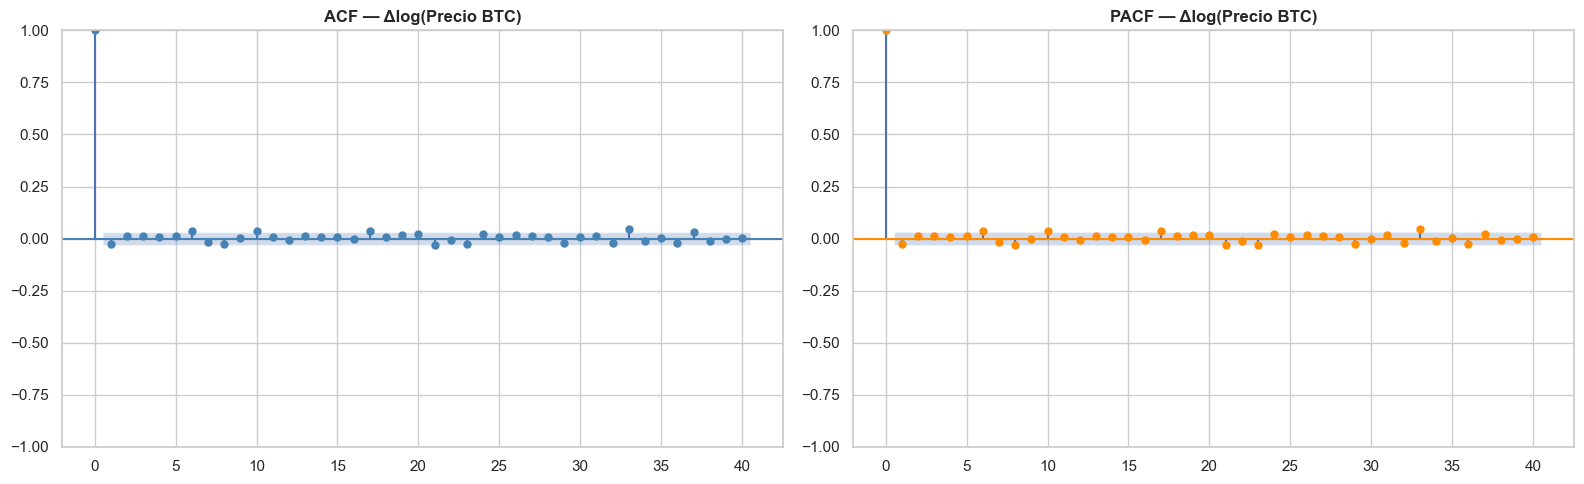

[FIGURA 4] El ACF y PACF muestran pocas correlaciones significativas más allá del lag 1, lo que sugiere órdenes bajos para p y q. Se explorarán órdenes en el rango [0,3] mediante búsqueda en grilla.


In [33]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

plot_acf(df['diff1'].dropna(), lags=40, ax=axes[0], color='steelblue')
axes[0].set_title('ACF — Δlog(Precio BTC)', fontweight='bold')

plot_pacf(df['diff1'].dropna(), lags=40, ax=axes[1], color='darkorange', method='ywm')
axes[1].set_title('PACF — Δlog(Precio BTC)', fontweight='bold')

plt.tight_layout()
plt.savefig('fig_04_acf_pacf.png', dpi=150, bbox_inches='tight')
plt.show()
print('[FIGURA 4] El ACF y PACF muestran pocas correlaciones significativas más allá del lag 1,'
      ' lo que sugiere órdenes bajos para p y q. Se explorarán órdenes en el rango [0,3] mediante búsqueda en grilla.')

---
## 4. Selección del mejor orden ARIMA — Criterios AIC, BIC, HQIC

In [34]:
# Usar el log del precio como serie de trabajo (d=1 internamente en ARIMA)
serie = df['log_close'].dropna()

# Usar solo los últimos 3 años para la búsqueda de orden (más rápido y representativo)
serie_fit = serie[-3*252:]

p_range = range(0, 4)
q_range = range(0, 4)
d = 1

resultados_grid = []
print('Buscando mejor orden ARIMA(p,1,q) — grilla p∈[0,3], q∈[0,3]...')

for p, q in itertools.product(p_range, q_range):
    try:
        modelo = ARIMA(serie_fit, order=(p, d, q))
        fit = modelo.fit()
        resultados_grid.append({
            'p': p, 'q': q,
            'AIC': round(fit.aic, 2),
            'BIC': round(fit.bic, 2),
            'HQIC': round(fit.hqic, 2)
        })
    except Exception:
        pass

df_grid = pd.DataFrame(resultados_grid)

order_aic  = (int(df_grid.loc[df_grid['AIC'].idxmin(), 'p']),  d, int(df_grid.loc[df_grid['AIC'].idxmin(), 'q']))
order_bic  = (int(df_grid.loc[df_grid['BIC'].idxmin(), 'p']),  d, int(df_grid.loc[df_grid['BIC'].idxmin(), 'q']))
order_hqic = (int(df_grid.loc[df_grid['HQIC'].idxmin(), 'p']), d, int(df_grid.loc[df_grid['HQIC'].idxmin(), 'q']))

print(f'\n✅ Mejor orden por AIC:  ARIMA{order_aic}  — AIC={df_grid["AIC"].min():.2f}')
print(f'✅ Mejor orden por BIC:  ARIMA{order_bic}  — BIC={df_grid["BIC"].min():.2f}')
print(f'✅ Mejor orden por HQIC: ARIMA{order_hqic} — HQIC={df_grid["HQIC"].min():.2f}')

print('\n=== Top 5 modelos por cada criterio ===')
for criterio in ['AIC', 'BIC', 'HQIC']:
    print(f'\nTop 5 por {criterio}:')
    print(df_grid.nsmallest(5, criterio)[['p', 'q', criterio]].to_string(index=False))

Buscando mejor orden ARIMA(p,1,q) — grilla p∈[0,3], q∈[0,3]...

✅ Mejor orden por AIC:  ARIMA(1, 1, 0)  — AIC=-3370.51
✅ Mejor orden por BIC:  ARIMA(0, 1, 0)  — BIC=-3363.43
✅ Mejor orden por HQIC: ARIMA(1, 1, 0) — HQIC=-3366.94

=== Top 5 modelos por cada criterio ===

Top 5 por AIC:
 p  q      AIC
 1  0 -3370.51
 0  1 -3370.33
 1  1 -3369.27
 2  0 -3368.85
 0  2 -3368.64

Top 5 por BIC:
 p  q      BIC
 0  0 -3363.43
 1  0 -3361.26
 0  1 -3361.08
 1  1 -3355.39
 2  0 -3354.97

Top 5 por HQIC:
 p  q     HQIC
 1  0 -3366.94
 0  1 -3366.77
 0  0 -3366.28
 1  1 -3363.93
 2  0 -3363.50


---
## 5. Diagnóstico de residuales del modelo ajustado

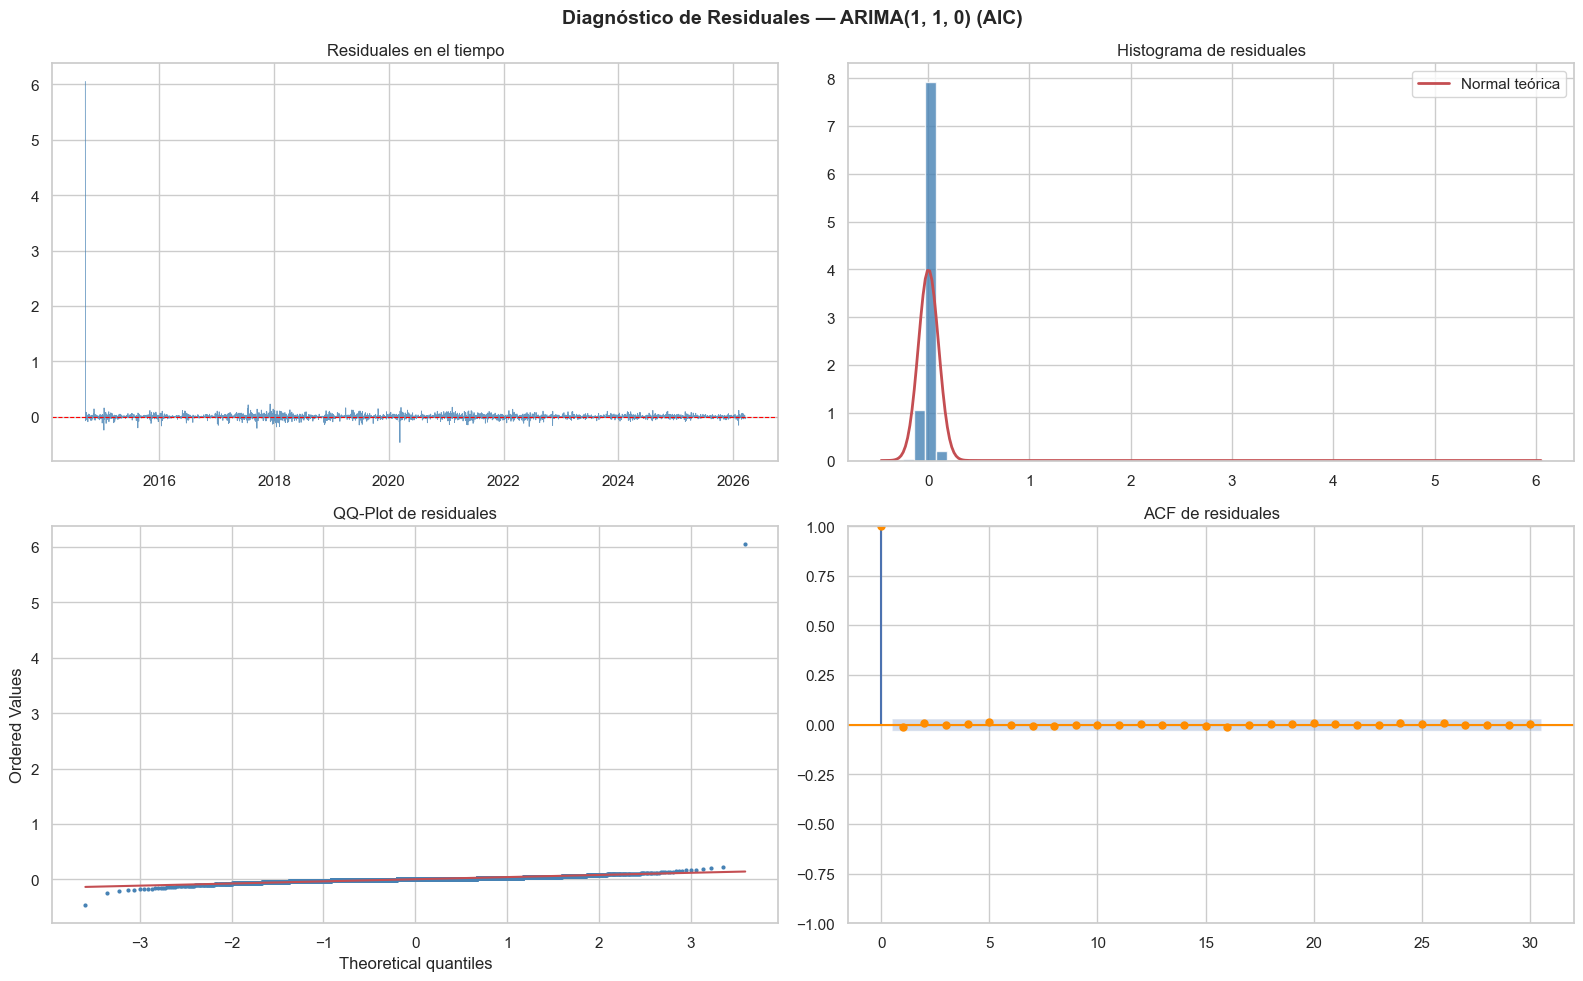


=== Tests estadísticos — ARIMA(1, 1, 0) (AIC) ===
Shapiro-Wilk (normalidad):  W=0.9451, p=0.0000 → No Normal ❌
Jarque-Bera  (normalidad):  JB=1805144890.1312, p=0.0000 → No Normal ❌
Ljung-Box (independencia residuales):
           Q   p-valor
10  1.843432  0.997405
20  3.428031  0.999987
Conclusión independencia: Residuales independientes ✅


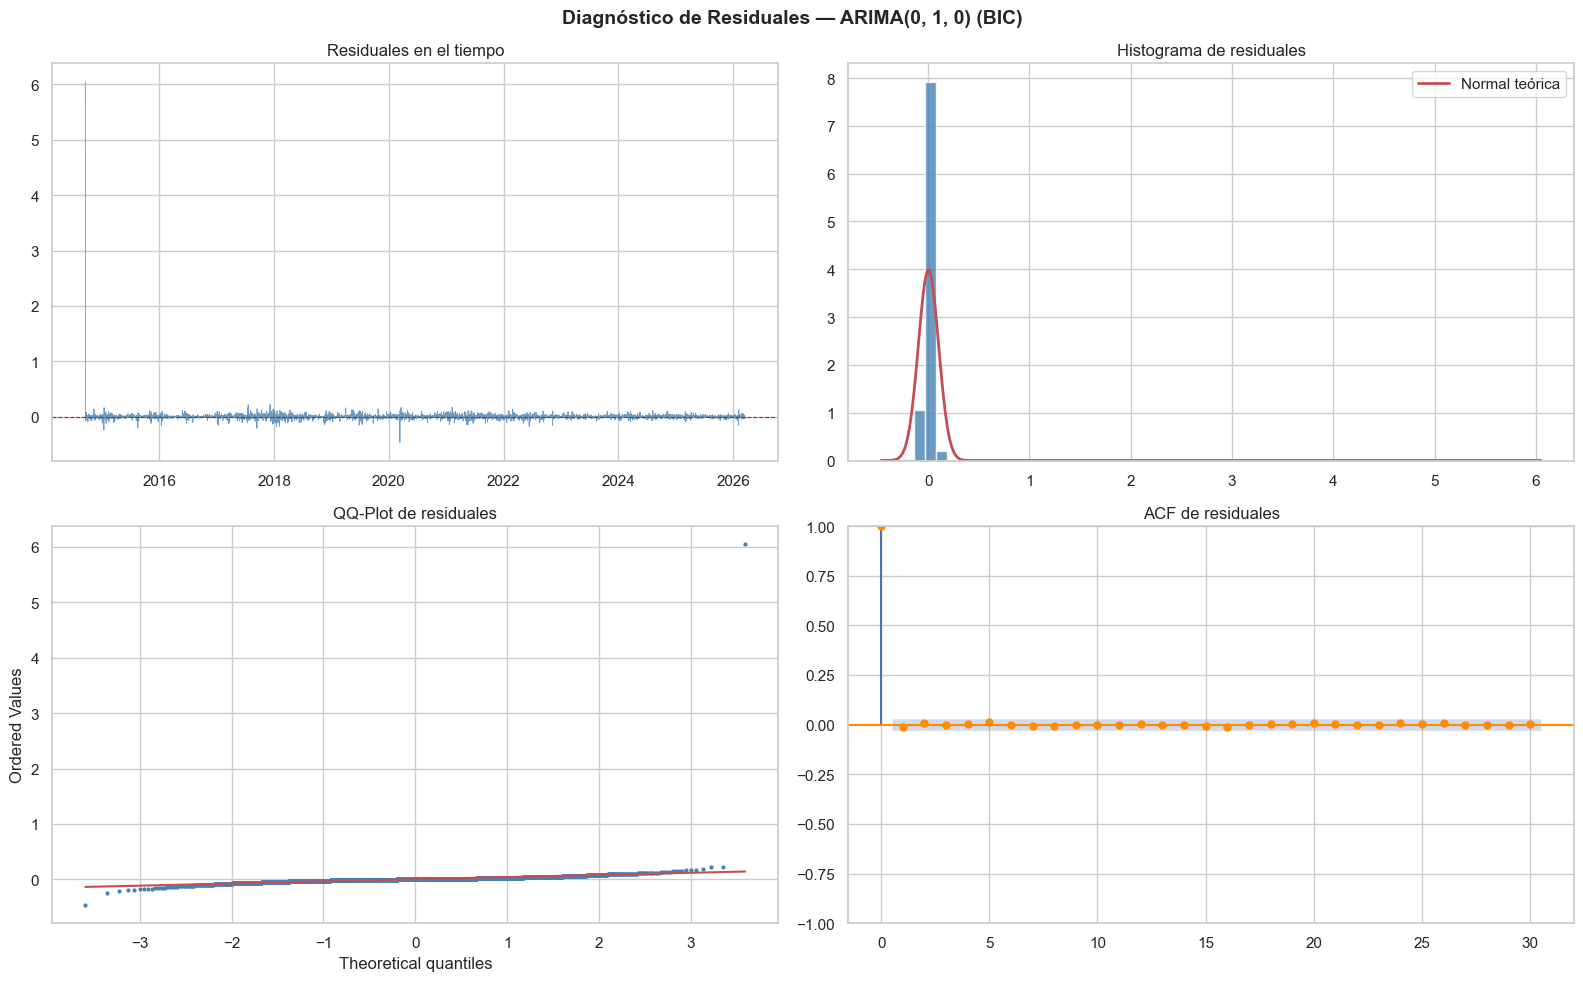


=== Tests estadísticos — ARIMA(0, 1, 0) (BIC) ===
Shapiro-Wilk (normalidad):  W=0.9446, p=0.0000 → No Normal ❌
Jarque-Bera  (normalidad):  JB=1804591744.5997, p=0.0000 → No Normal ❌
Ljung-Box (independencia residuales):
           Q   p-valor
10  2.140225  0.995148
20  3.705660  0.999975
Conclusión independencia: Residuales independientes ✅


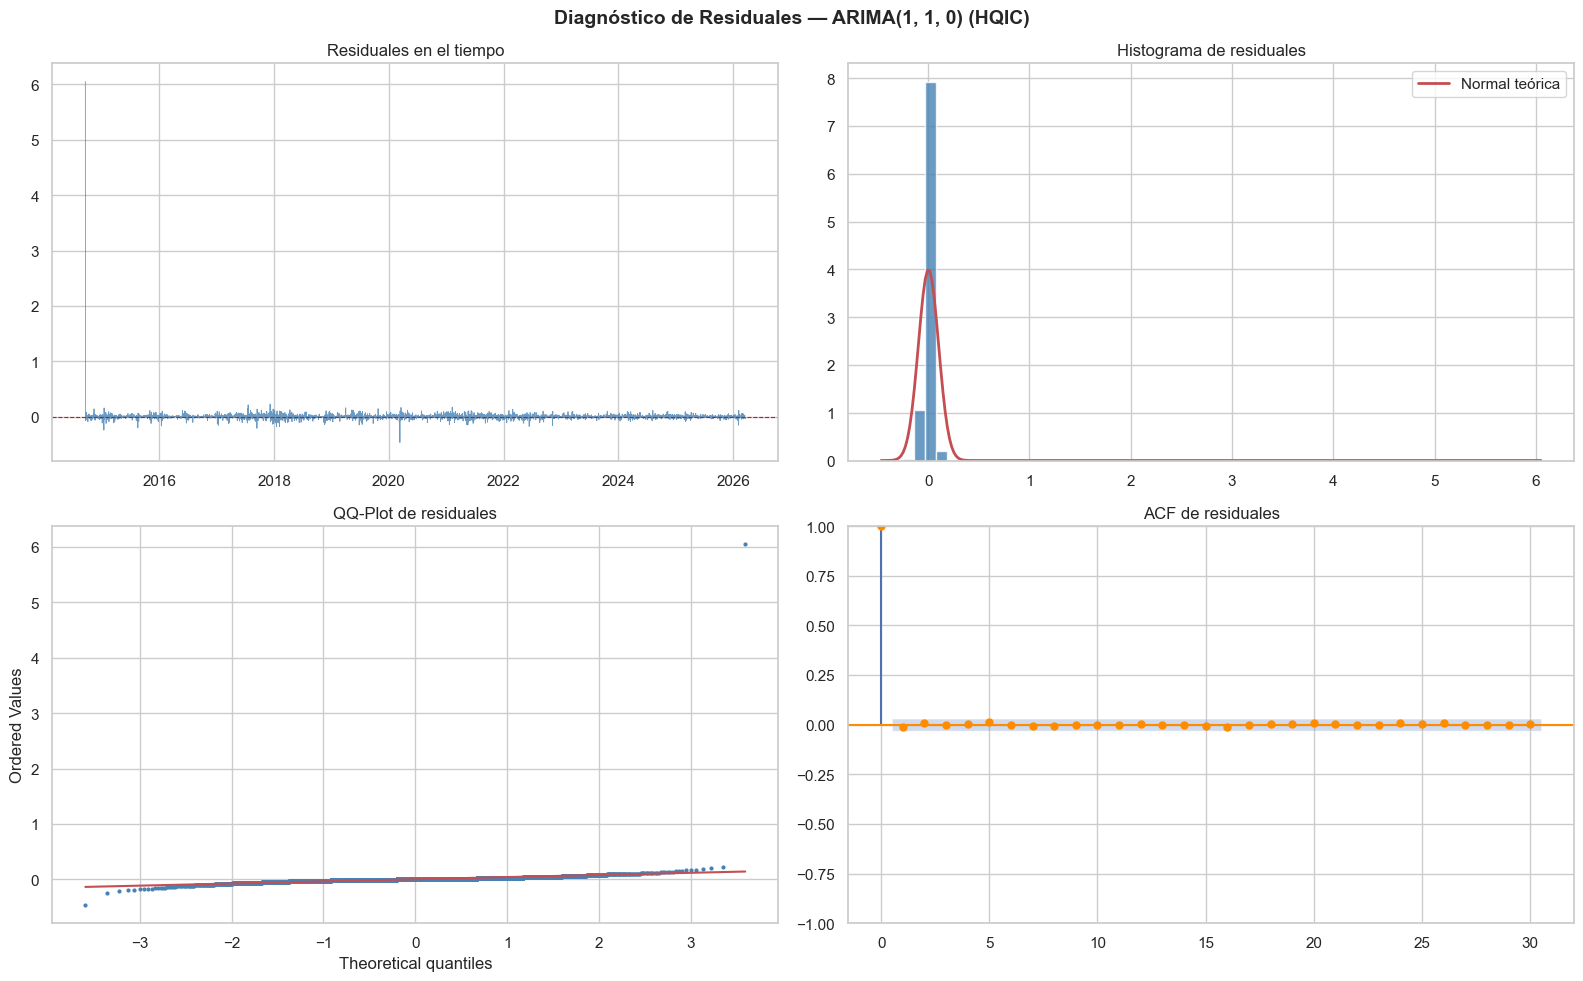


=== Tests estadísticos — ARIMA(1, 1, 0) (HQIC) ===
Shapiro-Wilk (normalidad):  W=0.9451, p=0.0000 → No Normal ❌
Jarque-Bera  (normalidad):  JB=1805144890.1312, p=0.0000 → No Normal ❌
Ljung-Box (independencia residuales):
           Q   p-valor
10  1.843432  0.997405
20  3.428031  0.999987
Conclusión independencia: Residuales independientes ✅


In [35]:
def diagnostico_residuales(orden, criterio_nombre, serie):
    """Ajusta ARIMA, grafica diagnóstico y realiza tests estadísticos."""
    modelo = ARIMA(serie, order=orden).fit()
    residuales = modelo.resid.dropna()

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle(f'Diagnóstico de Residuales — ARIMA{orden} ({criterio_nombre})', fontsize=14, fontweight='bold')

    # Residuales en el tiempo
    axes[0,0].plot(residuales, color='steelblue', linewidth=0.6, alpha=0.8)
    axes[0,0].axhline(0, color='red', linestyle='--', linewidth=0.8)
    axes[0,0].set_title('Residuales en el tiempo')

    # Histograma
    axes[0,1].hist(residuales, bins=60, density=True, color='steelblue', edgecolor='white', alpha=0.8)
    xr = np.linspace(residuales.min(), residuales.max(), 300)
    axes[0,1].plot(xr, stats.norm.pdf(xr, residuales.mean(), residuales.std()), 'r-', lw=2, label='Normal teórica')
    axes[0,1].set_title('Histograma de residuales')
    axes[0,1].legend()

    # QQ-plot
    stats.probplot(residuales, dist='norm', plot=axes[1,0])
    axes[1,0].set_title('QQ-Plot de residuales')
    axes[1,0].get_lines()[0].set(color='steelblue', markersize=2)

    # ACF residuales
    plot_acf(residuales, lags=30, ax=axes[1,1], color='darkorange')
    axes[1,1].set_title('ACF de residuales')

    plt.tight_layout()
    fname = f'fig_diag_{criterio_nombre}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()

    # Tests estadísticos
    sw_stat, sw_p   = shapiro(residuales[-500:])  # Shapiro en muestra pequeña
    jb_stat, jb_p   = jarque_bera(residuales)
    lb = acorr_ljungbox(residuales, lags=[10, 20], return_df=True)

    print(f'\n=== Tests estadísticos — ARIMA{orden} ({criterio_nombre}) ===')
    print(f'Shapiro-Wilk (normalidad):  W={sw_stat:.4f}, p={sw_p:.4f} → {"Normal ✅" if sw_p > 0.05 else "No Normal ❌"}')
    print(f'Jarque-Bera  (normalidad):  JB={jb_stat:.4f}, p={jb_p:.4f} → {"Normal ✅" if jb_p > 0.05 else "No Normal ❌"}')
    print('Ljung-Box (independencia residuales):')
    print(lb[['lb_stat', 'lb_pvalue']].rename(columns={'lb_stat': 'Q', 'lb_pvalue': 'p-valor'}).to_string())
    indep_ok = all(lb['lb_pvalue'] > 0.05)
    print(f'Conclusión independencia: {"Residuales independientes ✅" if indep_ok else "Autocorrelación detectada ❌"}')

    return modelo

modelo_aic  = diagnostico_residuales(order_aic,  'AIC',  serie)
modelo_bic  = diagnostico_residuales(order_bic,  'BIC',  serie)
modelo_hqic = diagnostico_residuales(order_hqic, 'HQIC', serie)

---
## 6. Funciones auxiliares de métricas

In [36]:
def calcular_metricas(y_real, y_pred, nombre=''):
    """Calcula MAPE, MAE, RMSE, MSE, R2."""
    y_real = np.array(y_real)
    y_pred = np.array(y_pred)
    mse  = mean_squared_error(y_real, y_pred)
    mae  = mean_absolute_error(y_real, y_pred)
    rmse = np.sqrt(mse)
    mape = np.mean(np.abs((y_real - y_pred) / y_real)) * 100  # en porcentaje
    r2   = r2_score(y_real, y_pred)
    return {'Modelo': nombre, 'MAPE (%)': round(mape, 4),
            'MAE': round(mae, 2), 'RMSE': round(rmse, 2),
            'MSE': round(mse, 2), 'R²': round(r2, 4)}

def graficar_correlacion(y_real, y_pred, titulo):
    """Gráfico de correlación real vs predicción."""
    y_real, y_pred = np.array(y_real), np.array(y_pred)
    corr = np.corrcoef(y_real, y_pred)[0,1]
    fig, ax = plt.subplots(figsize=(7, 6))
    ax.scatter(y_real, y_pred, alpha=0.6, color='steelblue', edgecolors='white', s=50)
    mn, mx = min(y_real.min(), y_pred.min()), max(y_real.max(), y_pred.max())
    ax.plot([mn, mx], [mn, mx], 'r--', lw=2, label='Línea perfecta')
    z = np.polyfit(y_real, y_pred, 1)
    p = np.poly1d(z)
    ax.plot(np.sort(y_real), p(np.sort(y_real)), 'g-', lw=1.5, alpha=0.7, label='Regresión ajustada')
    ax.set_xlabel('Valor Real (USD)', fontsize=12)
    ax.set_ylabel('Predicción (USD)', fontsize=12)
    ax.set_title(f'{titulo}\nCorrelación r = {corr:.4f}', fontsize=12, fontweight='bold')
    ax.legend()
    plt.tight_layout()
    fname = f'fig_corr_{titulo[:30].replace(" ","_")}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    return corr

def test_residuales_prediccion(y_real, y_pred, titulo):
    """Tests de normalidad e independencia sobre los residuales de predicción."""
    residuales = np.array(y_real) - np.array(y_pred)
    n = len(residuales)
    print(f'\n--- Residuales de predicción: {titulo} (n={n}) ---')

    # Normalidad — Jarque-Bera requiere n >= 8
    if n >= 8:
        jb_stat, jb_p = jarque_bera(residuales)
        print(f'Jarque-Bera: JB={jb_stat:.4f}, p={jb_p:.4f} → {"Normal ✅" if jb_p > 0.05 else "No Normal ❌"}')
    else:
        print('Jarque-Bera: muestra insuficiente (n<8), omitido')

    # Shapiro-Wilk requiere n >= 3
    if n >= 3:
        sw_stat, sw_p = shapiro(residuales)
        print(f'Shapiro-Wilk: W={sw_stat:.4f}, p={sw_p:.4f} → {"Normal ✅" if sw_p > 0.05 else "No Normal ❌"}')
    else:
        print('Shapiro-Wilk: muestra insuficiente (n<3), omitido')

    # Ljung-Box — lags debe ser < n
    max_lag = max(1, min(n - 1, 5))  # máximo 5 lags o n-1 si n es pequeño
    lb = acorr_ljungbox(residuales, lags=[max_lag], return_df=True)
    lb_p = lb['lb_pvalue'].values[0]
    print(f'Ljung-Box lag={max_lag}: Q={lb["lb_stat"].values[0]:.4f}, p={lb_p:.4f} → {"Independientes ✅" if lb_p > 0.05 else "Autocorrelación ❌"}')

print('Funciones auxiliares definidas ✅')

Funciones auxiliares definidas ✅


---
## 7. Pronóstico ROLLING — Ventana de predicción continua de un día

En el pronóstico rolling, el modelo se reajusta en cada paso incorporando la última observación disponible. Esto simula una predicción en tiempo real con actualización continua.

In [37]:
def rolling_forecast(serie_log, orden, h):
    """
    Pronóstico rolling: ventana de predicción continua de un día.
    - serie_log: serie en log-escala
    - orden: tuple (p, d, q)
    - h: horizonte (días de test)
    Retorna precios reales y predichos en escala original (USD).
    """
    train_log = serie_log.iloc[:-h]
    test_log  = serie_log.iloc[-h:]
    history   = list(train_log)
    preds_log = []

    for t in range(len(test_log)):
        try:
            fit = ARIMA(history, order=orden).fit()
            pred_log = fit.forecast(steps=1)[0]
        except Exception:
            pred_log = history[-1]  # fallback: naive
        preds_log.append(pred_log)
        history.append(float(test_log.iloc[t]))

    # Convertir de log a escala original
    y_real = np.exp(test_log.values)
    y_pred = np.exp(np.array(preds_log))
    fechas = test_log.index
    return fechas, y_real, y_pred

horizons = [7, 14, 21, 28]
criterios = {'AIC': order_aic, 'BIC': order_bic, 'HQIC': order_hqic}
serie_log = df['log_close'].dropna()

# Almacenar resultados rolling
rolling_results = {}   # {criterio: {h: (fechas, y_real, y_pred)}}
rolling_metricas = {}  # {criterio: DataFrame de métricas}

for crit, orden in criterios.items():
    rolling_results[crit] = {}
    metricas_crit = []
    print(f'\n====== ROLLING — {crit}: ARIMA{orden} ======')
    for h in horizons:
        fechas, y_real, y_pred = rolling_forecast(serie_log, orden, h)
        rolling_results[crit][h] = (fechas, y_real, y_pred)
        m = calcular_metricas(y_real, y_pred, nombre=f'h={h}')
        metricas_crit.append(m)
        print(f'  h={h:2d} | MAPE={m["MAPE (%)"]:.4f}% | RMSE={m["RMSE"]:,.2f} | R²={m["R²"]:.4f}')
    rolling_metricas[crit] = pd.DataFrame(metricas_crit).set_index('Modelo')

print('\n✅ Pronósticos rolling completados.')


====== ROLLING — AIC: ARIMA(1, 1, 0) ======
  h= 7 | MAPE=1.8596% | RMSE=1,570.74 | R²=0.0907
  h=14 | MAPE=1.9345% | RMSE=1,601.53 | R²=0.5440
  h=21 | MAPE=2.2134% | RMSE=1,862.06 | R²=0.4645
  h=28 | MAPE=2.1627% | RMSE=1,879.01 | R²=0.5011

====== ROLLING — BIC: ARIMA(0, 1, 0) ======
  h= 7 | MAPE=1.8399% | RMSE=1,552.90 | R²=0.1112
  h=14 | MAPE=1.9035% | RMSE=1,582.08 | R²=0.5550
  h=21 | MAPE=2.2118% | RMSE=1,861.90 | R²=0.4646
  h=28 | MAPE=2.1610% | RMSE=1,879.15 | R²=0.5010

====== ROLLING — HQIC: ARIMA(1, 1, 0) ======
  h= 7 | MAPE=1.8596% | RMSE=1,570.74 | R²=0.0907
  h=14 | MAPE=1.9345% | RMSE=1,601.53 | R²=0.5440
  h=21 | MAPE=2.2134% | RMSE=1,862.06 | R²=0.4645
  h=28 | MAPE=2.1627% | RMSE=1,879.01 | R²=0.5011

✅ Pronósticos rolling completados.


In [38]:
# Tablas de error rolling
for crit in criterios:
    print(f'\n=== Tabla de Error — Rolling — {crit}: ARIMA{criterios[crit]} ===')
    print(rolling_metricas[crit].to_string())


=== Tabla de Error — Rolling — AIC: ARIMA(1, 1, 0) ===
        MAPE (%)      MAE     RMSE         MSE      R²
Modelo                                                
h=7       1.8596  1344.75  1570.74  2467225.02  0.0907
h=14      1.9345  1357.91  1601.53  2564894.36  0.5440
h=21      2.2134  1546.86  1862.06  3467256.25  0.4645
h=28      2.1627  1494.63  1879.01  3530689.49  0.5011

=== Tabla de Error — Rolling — BIC: ARIMA(0, 1, 0) ===
        MAPE (%)      MAE     RMSE         MSE      R²
Modelo                                                
h=7       1.8399  1330.85  1552.90  2411502.93  0.1112
h=14      1.9035  1336.50  1582.08  2502964.96  0.5550
h=21      2.2118  1545.77  1861.90  3466679.88  0.4646
h=28      2.1610  1493.60  1879.15  3531220.32  0.5010

=== Tabla de Error — Rolling — HQIC: ARIMA(1, 1, 0) ===
        MAPE (%)      MAE     RMSE         MSE      R²
Modelo                                                
h=7       1.8596  1344.75  1570.74  2467225.02  0.0907
h=14  

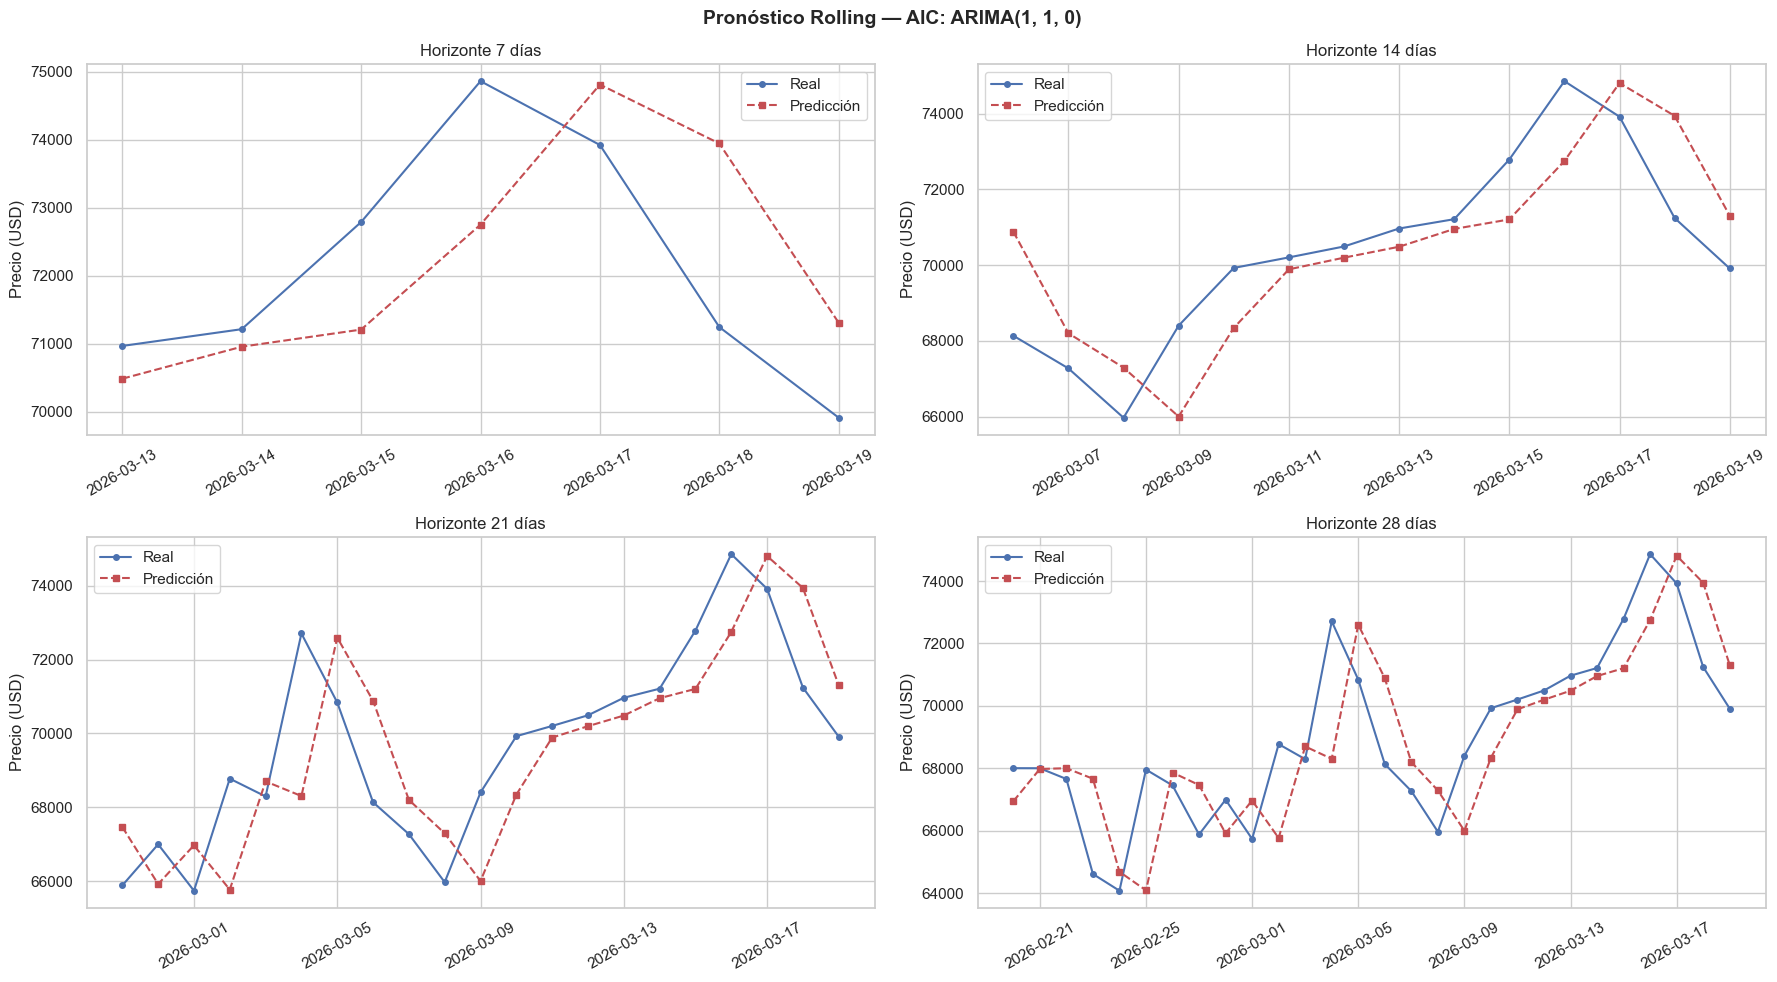

[FIGURA Rolling AIC] El pronóstico rolling captura bien los valores cercanos al período de entrenamiento, con mayor error a medida que se alarga el horizonte, lo que es esperable en series financieras.


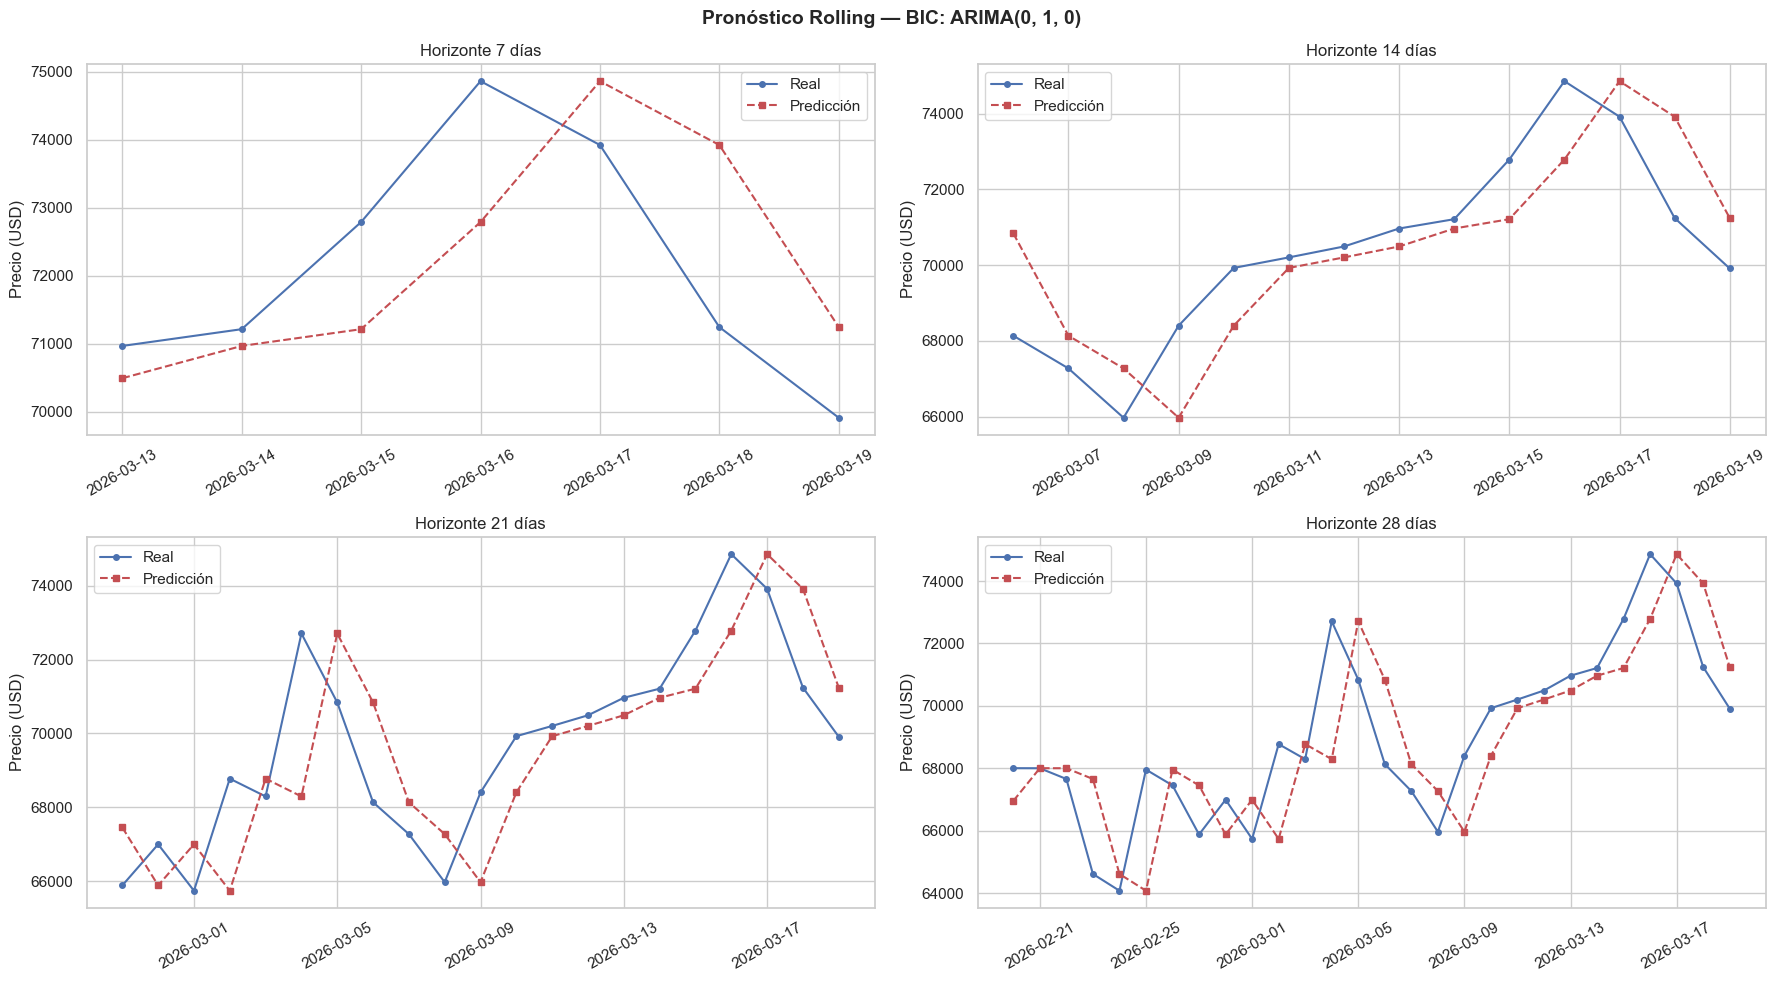

[FIGURA Rolling BIC] El pronóstico rolling captura bien los valores cercanos al período de entrenamiento, con mayor error a medida que se alarga el horizonte, lo que es esperable en series financieras.


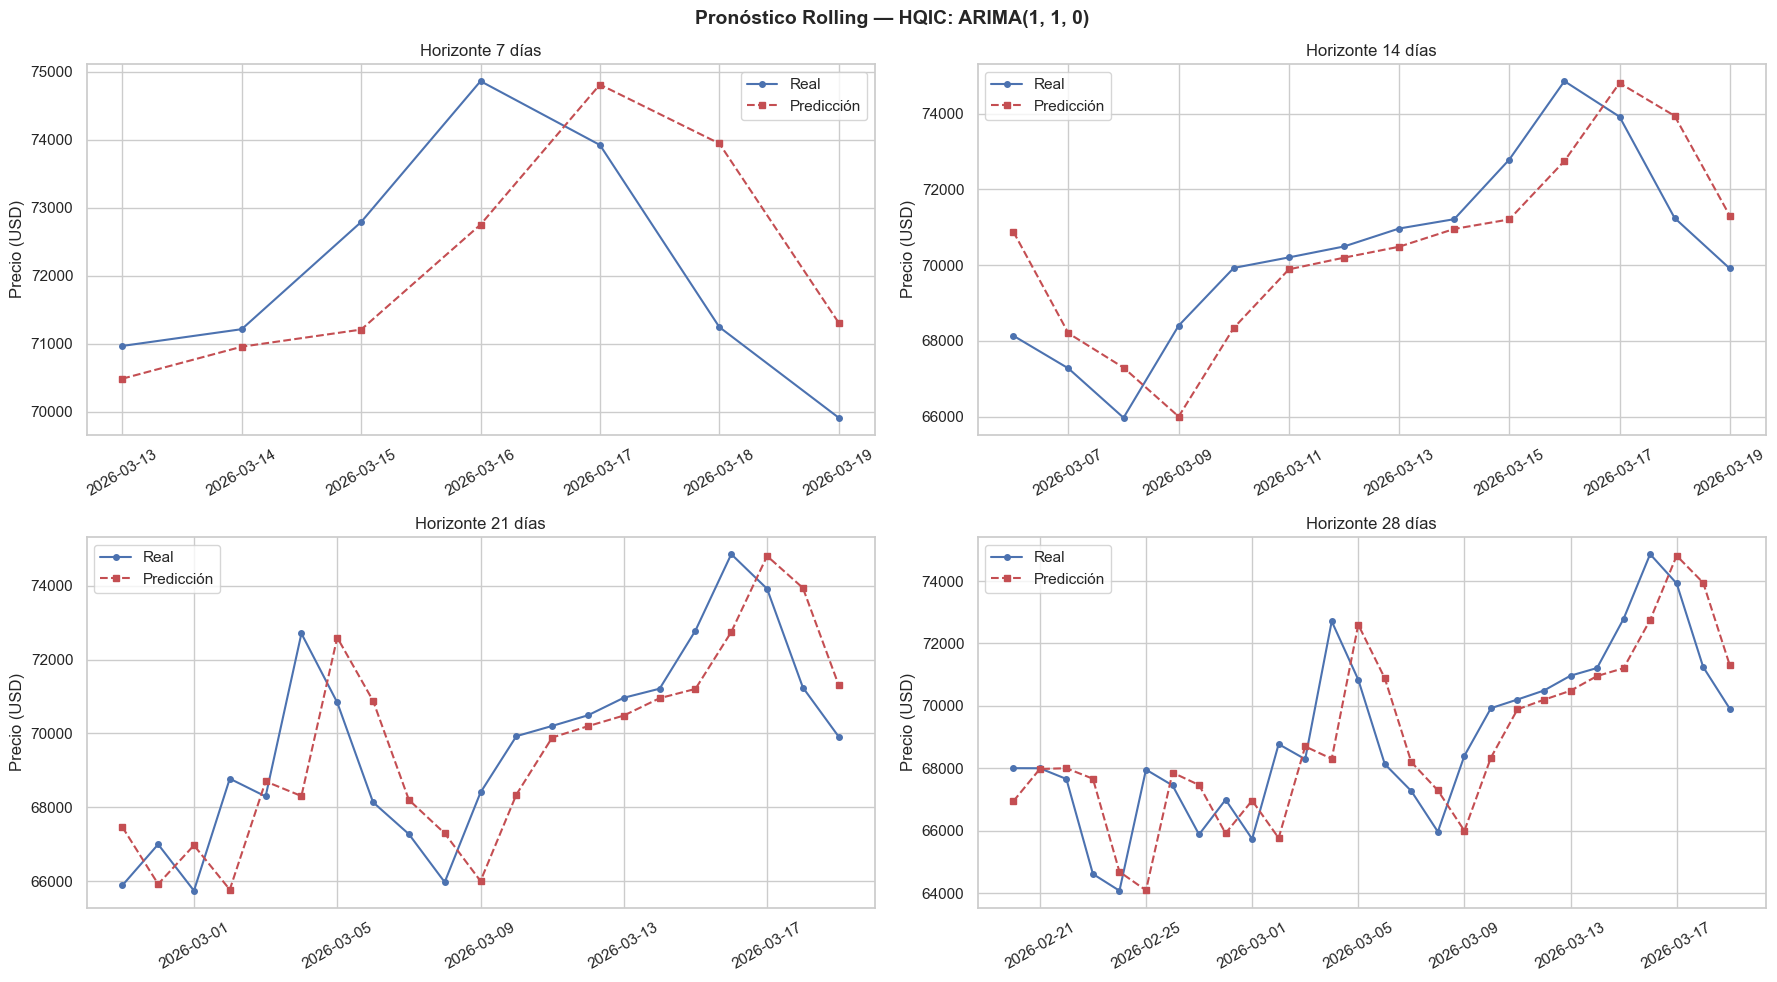

[FIGURA Rolling HQIC] El pronóstico rolling captura bien los valores cercanos al período de entrenamiento, con mayor error a medida que se alarga el horizonte, lo que es esperable en series financieras.


In [39]:
# Gráficos de predicción rolling
for crit, orden in criterios.items():
    fig, axes = plt.subplots(2, 2, figsize=(18, 10))
    fig.suptitle(f'Pronóstico Rolling — {crit}: ARIMA{orden}', fontsize=14, fontweight='bold')
    axes = axes.flatten()
    for i, h in enumerate(horizons):
        fechas, y_real, y_pred = rolling_results[crit][h]
        axes[i].plot(fechas, y_real, 'b-o', markersize=4, label='Real')
        axes[i].plot(fechas, y_pred, 'r--s', markersize=4, label='Predicción')
        axes[i].set_title(f'Horizonte {h} días')
        axes[i].set_ylabel('Precio (USD)')
        axes[i].legend()
        axes[i].tick_params(axis='x', rotation=30)
    plt.tight_layout()
    plt.savefig(f'fig_rolling_{crit}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'[FIGURA Rolling {crit}] El pronóstico rolling captura bien los valores cercanos al período de entrenamiento,'
          f' con mayor error a medida que se alarga el horizonte, lo que es esperable en series financieras.')


======== Correlación y Tests — Rolling AIC ========


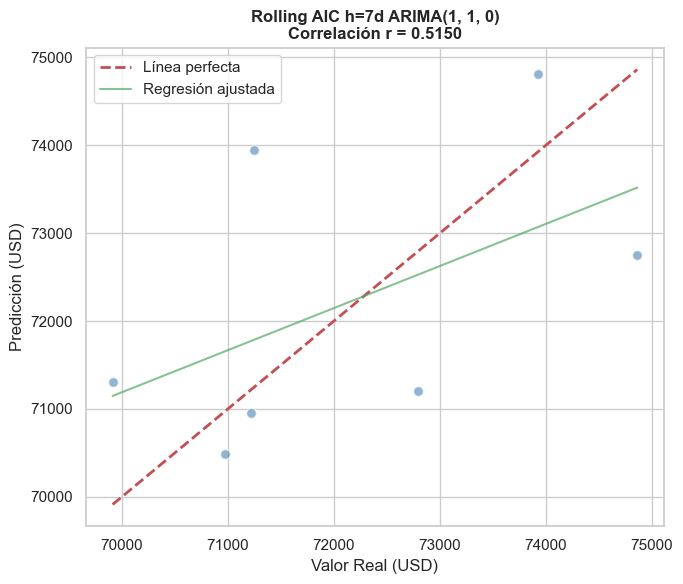


--- Residuales de predicción: Rolling AIC h=7d ARIMA(1, 1, 0) (n=7) ---
Jarque-Bera: muestra insuficiente (n<8), omitido
Shapiro-Wilk: W=0.9718, p=0.9112 → Normal ✅
Ljung-Box lag=5: Q=6.5256, p=0.2584 → Independientes ✅


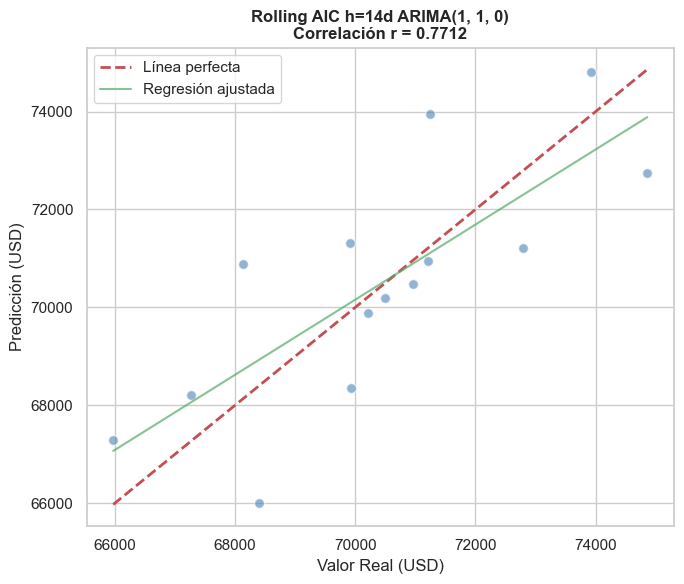


--- Residuales de predicción: Rolling AIC h=14d ARIMA(1, 1, 0) (n=14) ---
Jarque-Bera: JB=0.6660, p=0.7168 → Normal ✅
Shapiro-Wilk: W=0.9451, p=0.4875 → Normal ✅
Ljung-Box lag=5: Q=5.5123, p=0.3566 → Independientes ✅


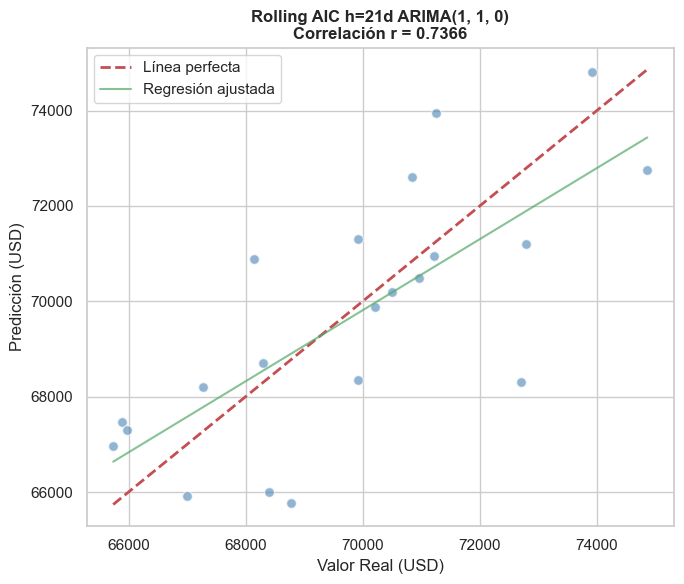


--- Residuales de predicción: Rolling AIC h=21d ARIMA(1, 1, 0) (n=21) ---
Jarque-Bera: JB=0.9229, p=0.6304 → Normal ✅
Shapiro-Wilk: W=0.9650, p=0.6230 → Normal ✅
Ljung-Box lag=5: Q=6.3819, p=0.2708 → Independientes ✅


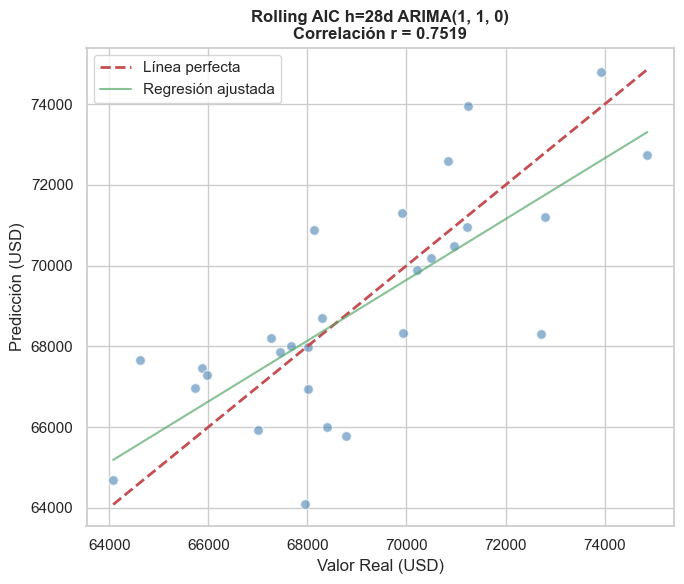


--- Residuales de predicción: Rolling AIC h=28d ARIMA(1, 1, 0) (n=28) ---
Jarque-Bera: JB=1.0977, p=0.5776 → Normal ✅
Shapiro-Wilk: W=0.9706, p=0.5972 → Normal ✅
Ljung-Box lag=5: Q=5.3240, p=0.3776 → Independientes ✅

======== Correlación y Tests — Rolling BIC ========


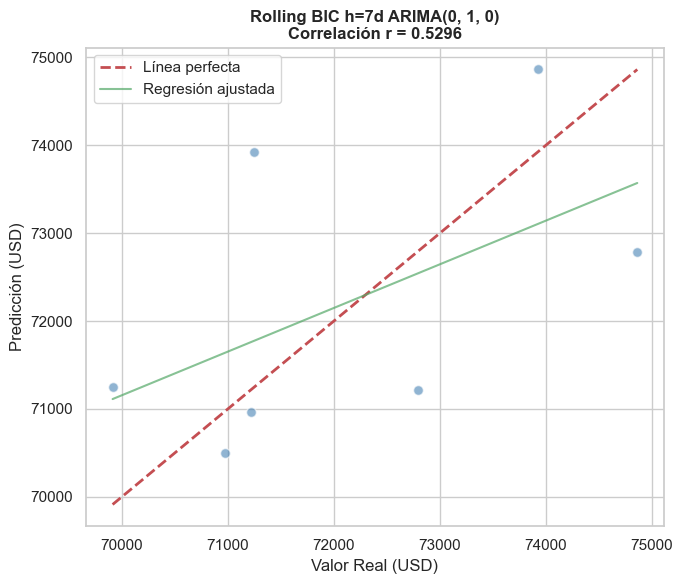


--- Residuales de predicción: Rolling BIC h=7d ARIMA(0, 1, 0) (n=7) ---
Jarque-Bera: muestra insuficiente (n<8), omitido
Shapiro-Wilk: W=0.9693, p=0.8933 → Normal ✅
Ljung-Box lag=5: Q=6.4417, p=0.2656 → Independientes ✅


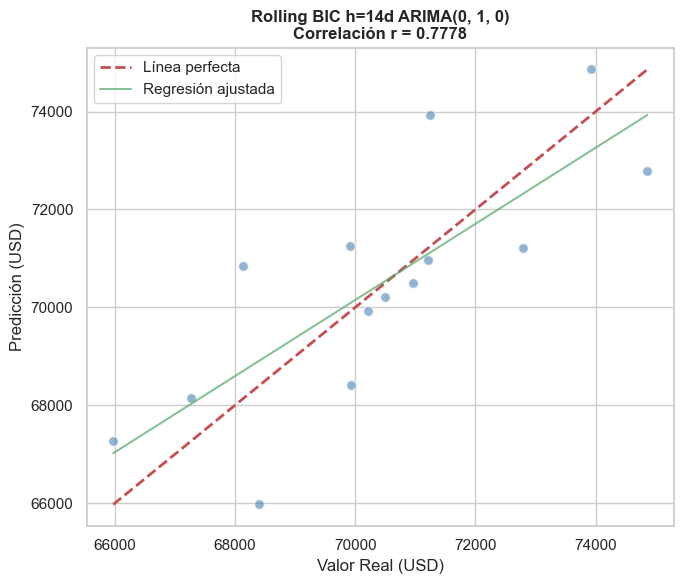


--- Residuales de predicción: Rolling BIC h=14d ARIMA(0, 1, 0) (n=14) ---
Jarque-Bera: JB=0.6270, p=0.7309 → Normal ✅
Shapiro-Wilk: W=0.9478, p=0.5264 → Normal ✅
Ljung-Box lag=5: Q=5.3147, p=0.3787 → Independientes ✅


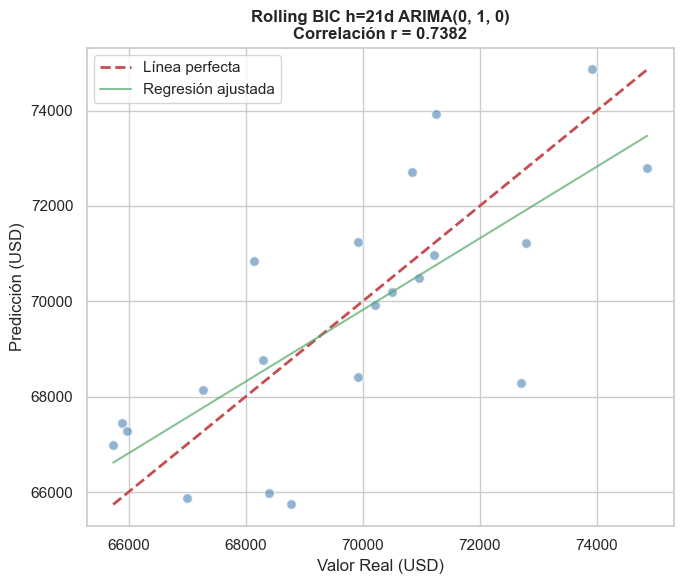


--- Residuales de predicción: Rolling BIC h=21d ARIMA(0, 1, 0) (n=21) ---
Jarque-Bera: JB=0.9815, p=0.6122 → Normal ✅
Shapiro-Wilk: W=0.9638, p=0.5952 → Normal ✅
Ljung-Box lag=5: Q=6.2087, p=0.2864 → Independientes ✅


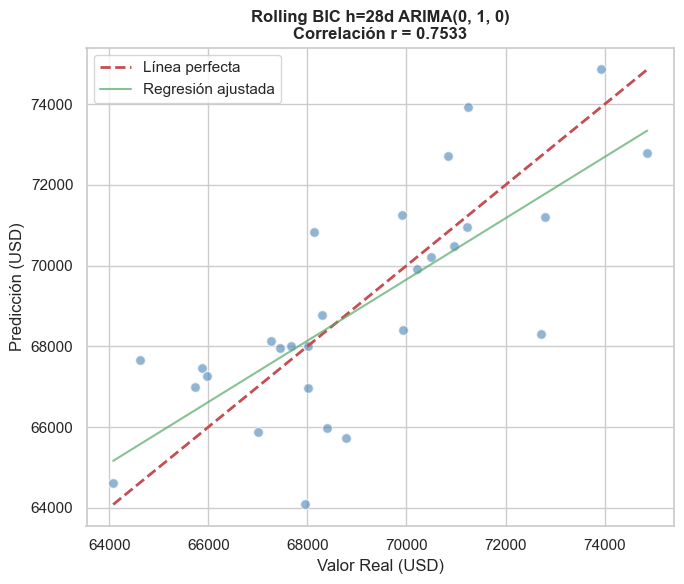


--- Residuales de predicción: Rolling BIC h=28d ARIMA(0, 1, 0) (n=28) ---
Jarque-Bera: JB=1.1840, p=0.5532 → Normal ✅
Shapiro-Wilk: W=0.9694, p=0.5638 → Normal ✅
Ljung-Box lag=5: Q=5.0884, p=0.4052 → Independientes ✅

======== Correlación y Tests — Rolling HQIC ========


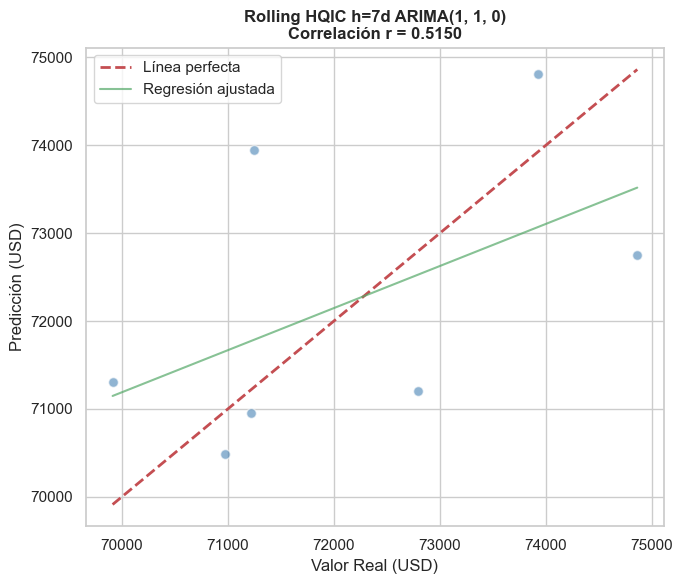


--- Residuales de predicción: Rolling HQIC h=7d ARIMA(1, 1, 0) (n=7) ---
Jarque-Bera: muestra insuficiente (n<8), omitido
Shapiro-Wilk: W=0.9718, p=0.9112 → Normal ✅
Ljung-Box lag=5: Q=6.5256, p=0.2584 → Independientes ✅


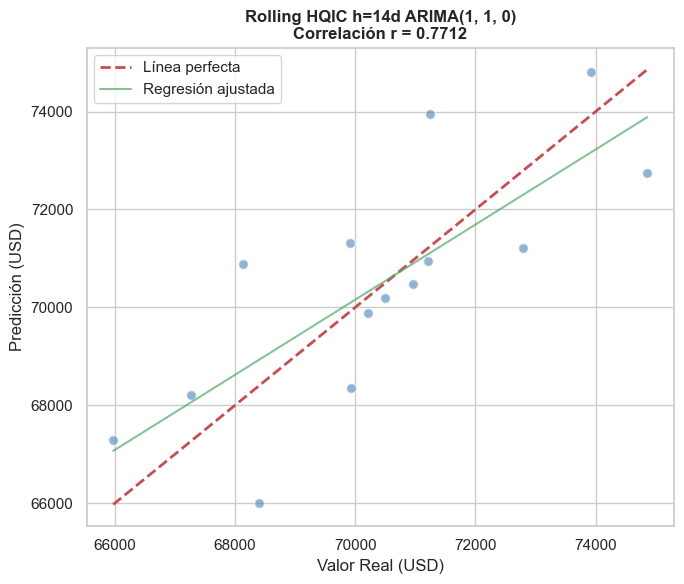


--- Residuales de predicción: Rolling HQIC h=14d ARIMA(1, 1, 0) (n=14) ---
Jarque-Bera: JB=0.6660, p=0.7168 → Normal ✅
Shapiro-Wilk: W=0.9451, p=0.4875 → Normal ✅
Ljung-Box lag=5: Q=5.5123, p=0.3566 → Independientes ✅


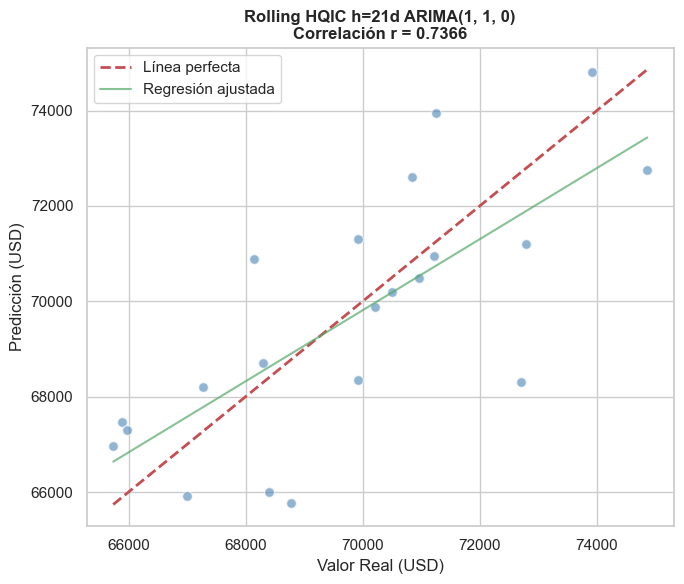


--- Residuales de predicción: Rolling HQIC h=21d ARIMA(1, 1, 0) (n=21) ---
Jarque-Bera: JB=0.9229, p=0.6304 → Normal ✅
Shapiro-Wilk: W=0.9650, p=0.6230 → Normal ✅
Ljung-Box lag=5: Q=6.3819, p=0.2708 → Independientes ✅


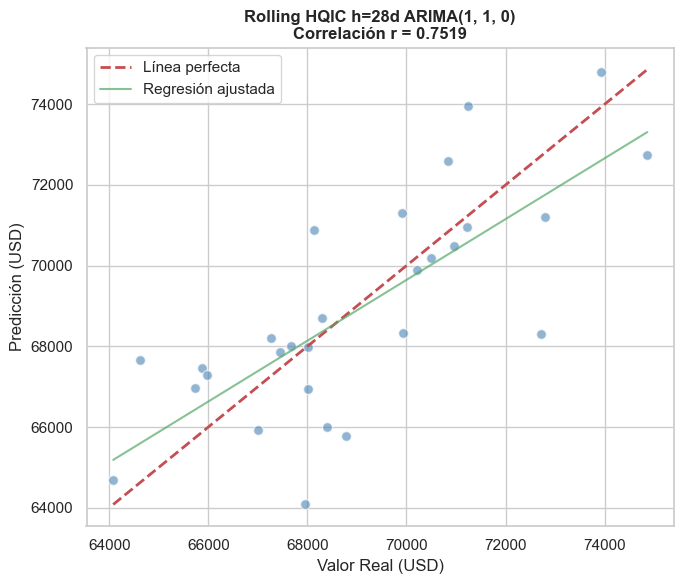


--- Residuales de predicción: Rolling HQIC h=28d ARIMA(1, 1, 0) (n=28) ---
Jarque-Bera: JB=1.0977, p=0.5776 → Normal ✅
Shapiro-Wilk: W=0.9706, p=0.5972 → Normal ✅
Ljung-Box lag=5: Q=5.3240, p=0.3776 → Independientes ✅


In [40]:
# Correlación y tests residuales rolling
for crit, orden in criterios.items():
    print(f'\n======== Correlación y Tests — Rolling {crit} ========')
    for h in horizons:
        fechas, y_real, y_pred = rolling_results[crit][h]
        titulo = f'Rolling {crit} h={h}d ARIMA{orden}'
        graficar_correlacion(y_real, y_pred, titulo)
        test_residuales_prediccion(y_real, y_pred, titulo)

---
## 8. Pronóstico ESTÁTICO — Usando forecast() sin rolling

El pronóstico estático usa el modelo ajustado una sola vez con todos los datos de entrenamiento y proyecta varios pasos hacia adelante. No incorpora nuevas observaciones en el proceso.

In [41]:
def static_forecast(serie_log, orden, h):
    """
    Pronóstico estático: ajusta el modelo una vez y proyecta h pasos.
    """
    train_log = serie_log.iloc[:-h]
    test_log  = serie_log.iloc[-h:]
    fit       = ARIMA(train_log, order=orden).fit()
    forecast  = fit.forecast(steps=h)
    y_real    = np.exp(test_log.values)
    y_pred    = np.exp(forecast.values)
    fechas    = test_log.index
    return fechas, y_real, y_pred

static_results  = {}
static_metricas = {}

for crit, orden in criterios.items():
    static_results[crit] = {}
    metricas_crit = []
    print(f'\n====== ESTÁTICO — {crit}: ARIMA{orden} ======')
    for h in horizons:
        fechas, y_real, y_pred = static_forecast(serie_log, orden, h)
        static_results[crit][h] = (fechas, y_real, y_pred)
        m = calcular_metricas(y_real, y_pred, nombre=f'h={h}')
        metricas_crit.append(m)
        print(f'  h={h:2d} | MAPE={m["MAPE (%)"]:.4f}% | RMSE={m["RMSE"]:,.2f} | R²={m["R²"]:.4f}')
    static_metricas[crit] = pd.DataFrame(metricas_crit).set_index('Modelo')

print('\n✅ Pronósticos estáticos completados.')


====== ESTÁTICO — AIC: ARIMA(1, 1, 0) ======
  h= 7 | MAPE=2.4632% | RMSE=2,327.24 | R²=-0.9961
  h=14 | MAPE=2.7067% | RMSE=2,424.90 | R²=-0.0454
  h=21 | MAPE=3.9234% | RMSE=3,413.56 | R²=-0.7996
  h=28 | MAPE=3.7806% | RMSE=3,368.88 | R²=-0.6036

====== ESTÁTICO — BIC: ARIMA(0, 1, 0) ======
  h= 7 | MAPE=2.4565% | RMSE=2,322.45 | R²=-0.9879
  h=14 | MAPE=2.6961% | RMSE=2,416.05 | R²=-0.0378
  h=21 | MAPE=3.9318% | RMSE=3,421.35 | R²=-0.8079
  h=28 | MAPE=3.7694% | RMSE=3,361.31 | R²=-0.5964

====== ESTÁTICO — HQIC: ARIMA(1, 1, 0) ======
  h= 7 | MAPE=2.4632% | RMSE=2,327.24 | R²=-0.9961
  h=14 | MAPE=2.7067% | RMSE=2,424.90 | R²=-0.0454
  h=21 | MAPE=3.9234% | RMSE=3,413.56 | R²=-0.7996
  h=28 | MAPE=3.7806% | RMSE=3,368.88 | R²=-0.6036

✅ Pronósticos estáticos completados.


In [42]:
# Tablas de error estático
for crit in criterios:
    print(f'\n=== Tabla de Error — Estático — {crit}: ARIMA{criterios[crit]} ===')
    print(static_metricas[crit].to_string())


=== Tabla de Error — Estático — AIC: ARIMA(1, 1, 0) ===
        MAPE (%)      MAE     RMSE          MSE      R²
Modelo                                                 
h=7       2.4632  1807.99  2327.24   5416026.85 -0.9961
h=14      2.7067  1889.56  2424.90   5880154.99 -0.0454
h=21      3.9234  2796.30  3413.56  11652383.77 -0.7996
h=28      3.7806  2669.72  3368.88  11349379.88 -0.6036

=== Tabla de Error — Estático — BIC: ARIMA(0, 1, 0) ===
        MAPE (%)      MAE     RMSE          MSE      R²
Modelo                                                 
h=7       2.4565  1803.12  2322.45   5393767.21 -0.9879
h=14      2.6961  1883.21  2416.05   5837285.59 -0.0378
h=21      3.9318  2802.40  3421.35  11705644.65 -0.8079
h=28      3.7694  2661.75  3361.31  11298386.03 -0.5964

=== Tabla de Error — Estático — HQIC: ARIMA(1, 1, 0) ===
        MAPE (%)      MAE     RMSE          MSE      R²
Modelo                                                 
h=7       2.4632  1807.99  2327.24   5416026

In [ ]:
# Gráficos pronóstico estático
for crit, orden in criterios.items():
    fig, axes = plt.subplots(2, 2, figsize=(18, 10))
    fig.suptitle(f'Pronóstico Estático — {crit}: ARIMA{orden}', fontsize=14, fontweight='bold')
    axes = axes.flatten()
    for i, h in enumerate(horizons):
        fechas, y_real, y_pred = static_results[crit][h]
        axes[i].plot(fechas, y_real, 'b-o', markersize=4, label='Real')
        axes[i].plot(fechas, y_pred, 'r--s', markersize=4, label='Predicción estática')
        axes[i].set_title(f'Horizonte {h} días')
        axes[i].set_ylabel('Precio (USD)')
        axes[i].legend()
        axes[i].tick_params(axis='x', rotation=30)
    plt.tight_layout()
    plt.savefig(f'fig_static_{crit}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'[FIGURA Estático {crit}] El pronóstico estático tiende a converger hacia la media de largo plazo'
          f' rápidamente, especialmente en horizontes largos, perdiendo capacidad predictiva.')


======== Correlación y Tests — Estático AIC ========


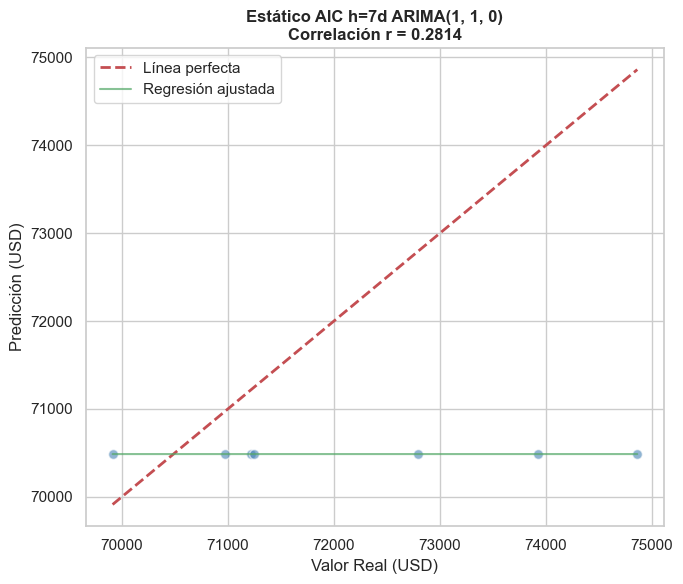


--- Residuales de predicción: Estático AIC h=7d ARIMA(1, 1, 0) (n=7) ---
Jarque-Bera: muestra insuficiente (n<8), omitido
Shapiro-Wilk: W=0.9291, p=0.5434 → Normal ✅
Ljung-Box lag=5: Q=11.1420, p=0.0486 → Autocorrelación ❌


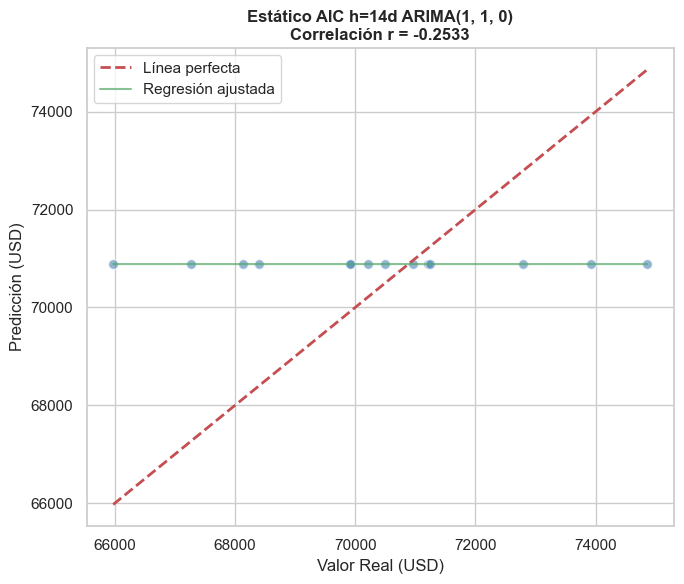


--- Residuales de predicción: Estático AIC h=14d ARIMA(1, 1, 0) (n=14) ---
Jarque-Bera: JB=0.1600, p=0.9231 → Normal ✅
Shapiro-Wilk: W=0.9780, p=0.9616 → Normal ✅
Ljung-Box lag=5: Q=14.8907, p=0.0108 → Autocorrelación ❌


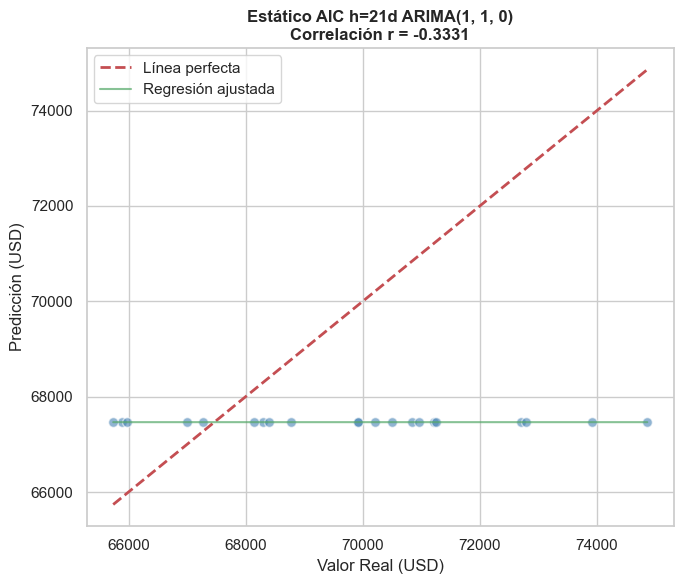


--- Residuales de predicción: Estático AIC h=21d ARIMA(1, 1, 0) (n=21) ---
Jarque-Bera: JB=0.5978, p=0.7416 → Normal ✅
Shapiro-Wilk: W=0.9671, p=0.6684 → Normal ✅
Ljung-Box lag=5: Q=15.5932, p=0.0081 → Autocorrelación ❌


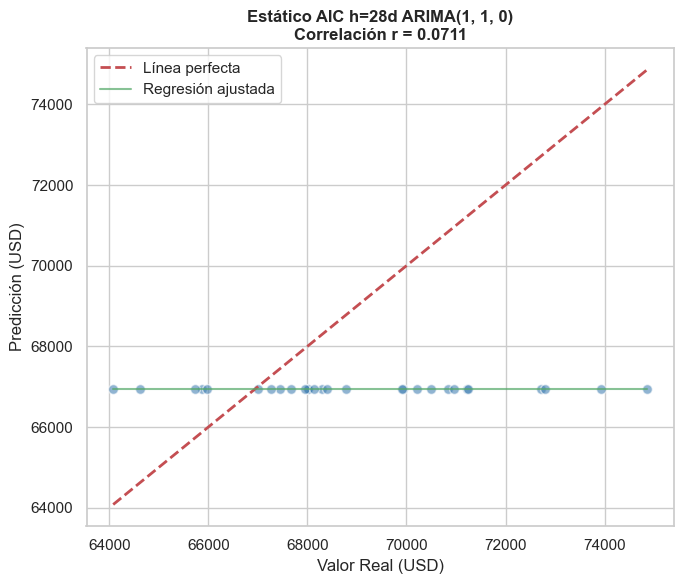


--- Residuales de predicción: Estático AIC h=28d ARIMA(1, 1, 0) (n=28) ---
Jarque-Bera: JB=0.6136, p=0.7358 → Normal ✅
Shapiro-Wilk: W=0.9778, p=0.7950 → Normal ✅
Ljung-Box lag=5: Q=31.0034, p=0.0000 → Autocorrelación ❌

======== Correlación y Tests — Estático BIC ========


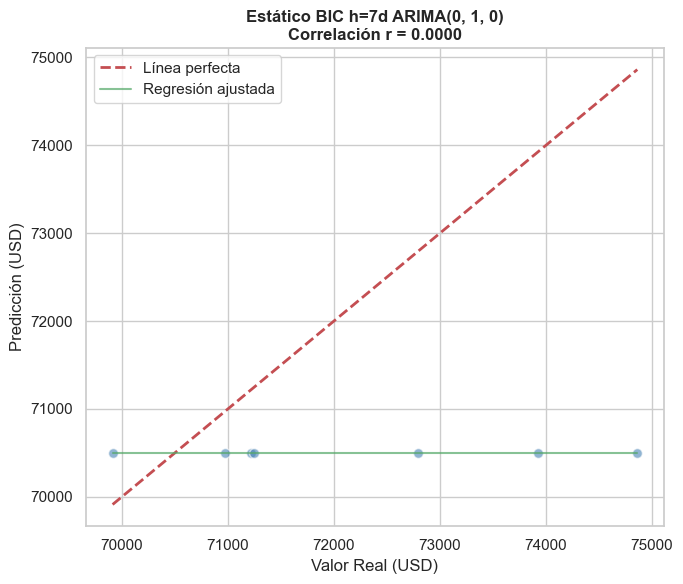


--- Residuales de predicción: Estático BIC h=7d ARIMA(0, 1, 0) (n=7) ---
Jarque-Bera: muestra insuficiente (n<8), omitido
Shapiro-Wilk: W=0.9291, p=0.5435 → Normal ✅
Ljung-Box lag=5: Q=11.1421, p=0.0486 → Autocorrelación ❌


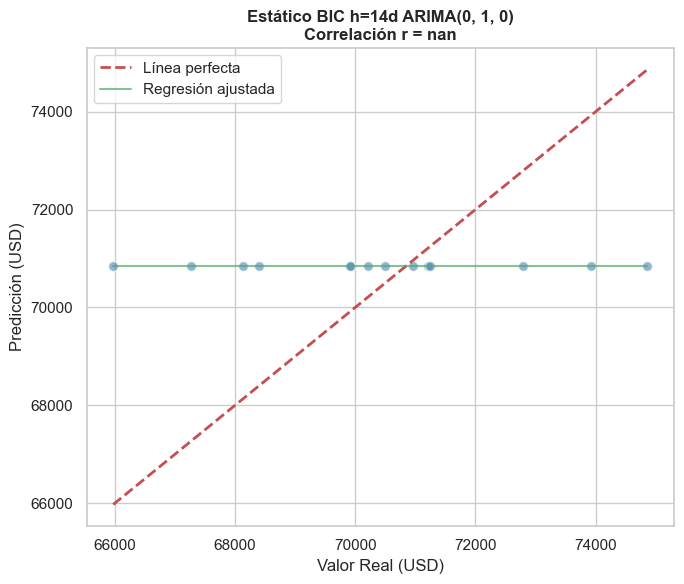


--- Residuales de predicción: Estático BIC h=14d ARIMA(0, 1, 0) (n=14) ---
Jarque-Bera: JB=0.1599, p=0.9232 → Normal ✅
Shapiro-Wilk: W=0.9780, p=0.9616 → Normal ✅
Ljung-Box lag=5: Q=14.8900, p=0.0108 → Autocorrelación ❌


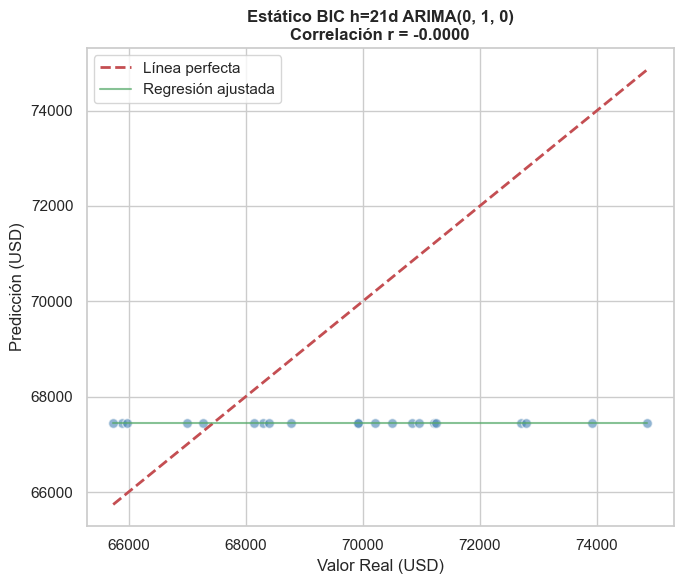


--- Residuales de predicción: Estático BIC h=21d ARIMA(0, 1, 0) (n=21) ---
Jarque-Bera: JB=0.5979, p=0.7416 → Normal ✅
Shapiro-Wilk: W=0.9671, p=0.6684 → Normal ✅
Ljung-Box lag=5: Q=15.5933, p=0.0081 → Autocorrelación ❌


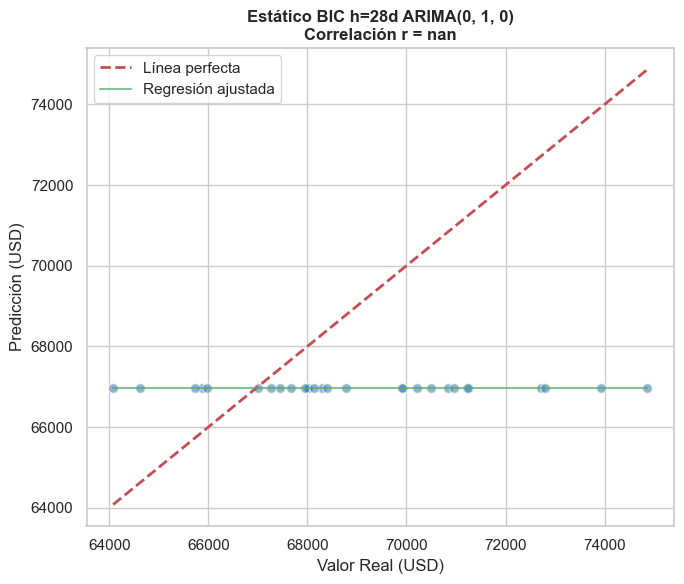


--- Residuales de predicción: Estático BIC h=28d ARIMA(0, 1, 0) (n=28) ---
Jarque-Bera: JB=0.6136, p=0.7358 → Normal ✅
Shapiro-Wilk: W=0.9778, p=0.7949 → Normal ✅
Ljung-Box lag=5: Q=31.0036, p=0.0000 → Autocorrelación ❌

======== Correlación y Tests — Estático HQIC ========


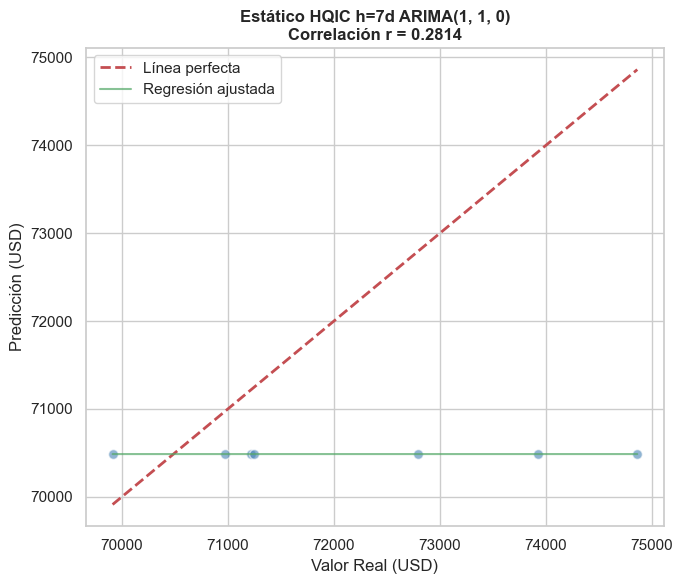


--- Residuales de predicción: Estático HQIC h=7d ARIMA(1, 1, 0) (n=7) ---
Jarque-Bera: muestra insuficiente (n<8), omitido
Shapiro-Wilk: W=0.9291, p=0.5434 → Normal ✅
Ljung-Box lag=5: Q=11.1420, p=0.0486 → Autocorrelación ❌


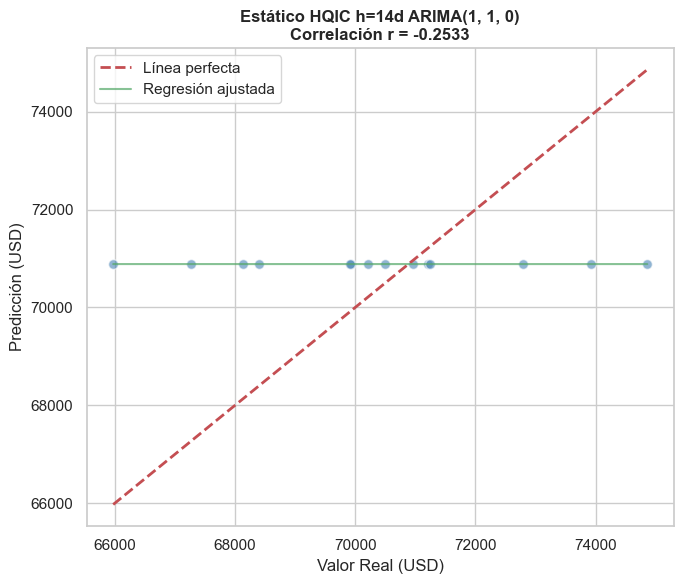


--- Residuales de predicción: Estático HQIC h=14d ARIMA(1, 1, 0) (n=14) ---
Jarque-Bera: JB=0.1600, p=0.9231 → Normal ✅
Shapiro-Wilk: W=0.9780, p=0.9616 → Normal ✅
Ljung-Box lag=5: Q=14.8907, p=0.0108 → Autocorrelación ❌


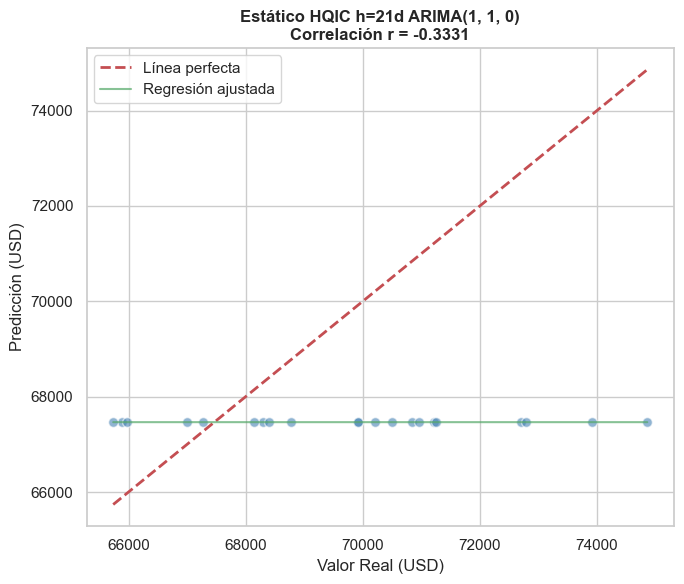


--- Residuales de predicción: Estático HQIC h=21d ARIMA(1, 1, 0) (n=21) ---
Jarque-Bera: JB=0.5978, p=0.7416 → Normal ✅
Shapiro-Wilk: W=0.9671, p=0.6684 → Normal ✅
Ljung-Box lag=5: Q=15.5932, p=0.0081 → Autocorrelación ❌


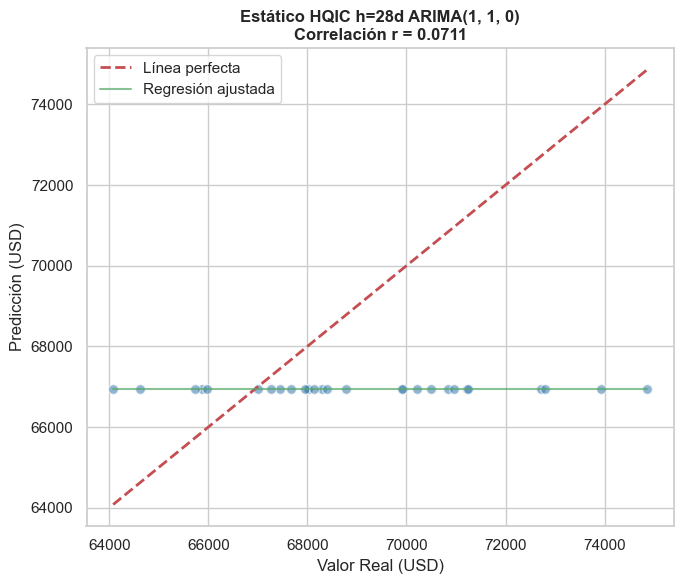


--- Residuales de predicción: Estático HQIC h=28d ARIMA(1, 1, 0) (n=28) ---
Jarque-Bera: JB=0.6136, p=0.7358 → Normal ✅
Shapiro-Wilk: W=0.9778, p=0.7950 → Normal ✅
Ljung-Box lag=5: Q=31.0034, p=0.0000 → Autocorrelación ❌


In [ ]:
# Correlación y tests residuales estático
for crit, orden in criterios.items():
    print(f'\n======== Correlación y Tests — Estático {crit} ========')
    for h in horizons:
        fechas, y_real, y_pred = static_results[crit][h]
        titulo = f'Estático {crit} h={h}d ARIMA{orden}'
        graficar_correlacion(y_real, y_pred, titulo)
        test_residuales_prediccion(y_real, y_pred, titulo)

---
## 9. Comparación global: Rolling vs Estático — Todos los criterios

In [ ]:
# Tabla comparativa completa
filas = []
for crit in criterios:
    for h in horizons:
        _, yr_r, yp_r = rolling_results[crit][h]
        _, yr_s, yp_s = static_results[crit][h]
        mr = calcular_metricas(yr_r, yp_r)
        ms = calcular_metricas(yr_s, yp_s)
        filas.append({
            'Criterio': crit, 'Método': 'Rolling', 'Horizonte': h,
            **{k: v for k, v in mr.items() if k != 'Modelo'}
        })
        filas.append({
            'Criterio': crit, 'Método': 'Estático', 'Horizonte': h,
            **{k: v for k, v in ms.items() if k != 'Modelo'}
        })

df_comp = pd.DataFrame(filas)
print('=== TABLA COMPARATIVA COMPLETA ===')
print(df_comp.to_string(index=False))

=== TABLA COMPARATIVA COMPLETA ===
Criterio   Método  Horizonte  MAPE (%)     MAE    RMSE         MSE      R²
     AIC  Rolling          7    1.8596 1344.75 1570.74  2467225.02  0.0907
     AIC Estático          7    2.4632 1807.99 2327.24  5416026.85 -0.9961
     AIC  Rolling         14    1.9345 1357.91 1601.53  2564894.36  0.5440
     AIC Estático         14    2.7067 1889.56 2424.90  5880154.99 -0.0454
     AIC  Rolling         21    2.2134 1546.86 1862.06  3467256.25  0.4645
     AIC Estático         21    3.9234 2796.30 3413.56 11652383.77 -0.7996
     AIC  Rolling         28    2.1627 1494.63 1879.01  3530689.49  0.5011
     AIC Estático         28    3.7806 2669.72 3368.88 11349379.88 -0.6036
     BIC  Rolling          7    1.8399 1330.85 1552.90  2411502.93  0.1112
     BIC Estático          7    2.4565 1803.12 2322.45  5393767.21 -0.9879
     BIC  Rolling         14    1.9035 1336.50 1582.08  2502964.96  0.5550
     BIC Estático         14    2.6961 1883.21 2416.05  5837285.5

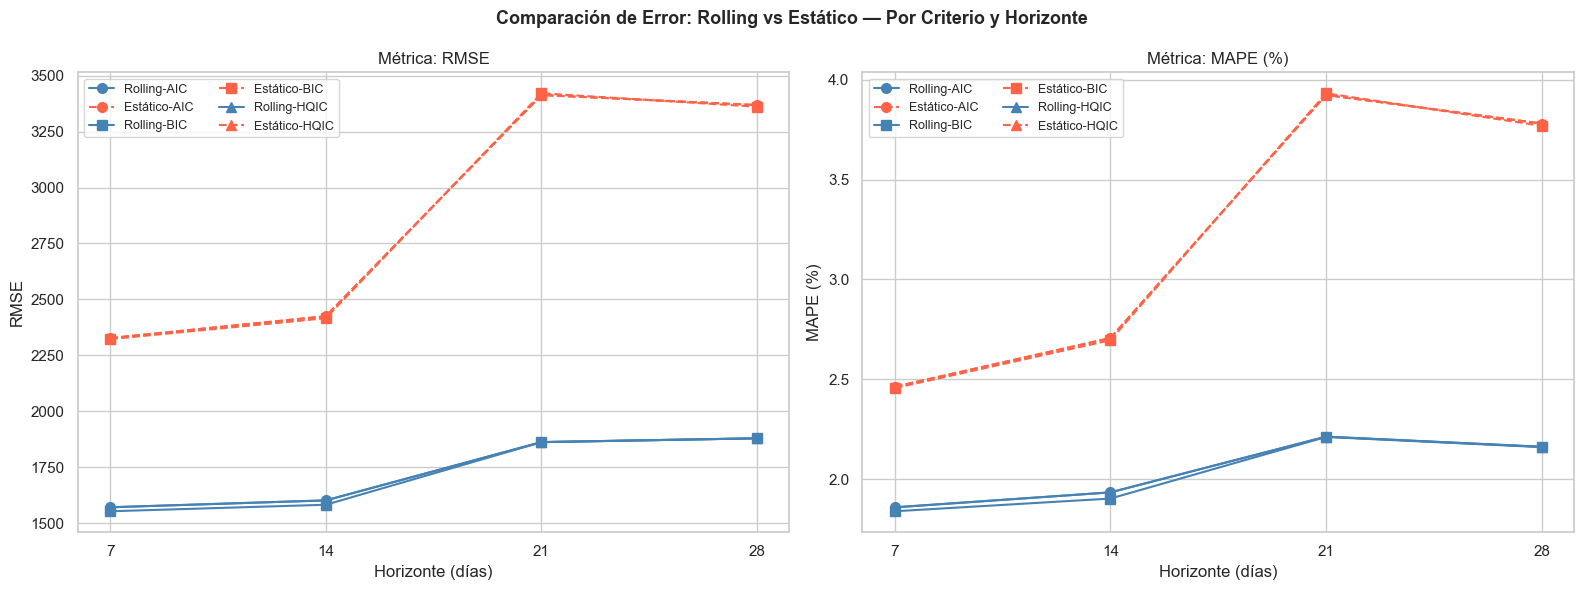

[FIGURA Comparación Global] El método rolling consistentemente supera al estático en RMSE y MAPE para todos los horizontes, dado que incorpora información más reciente en cada predicción.


In [ ]:
# Visualización comparativa — RMSE y MAPE por método y criterio
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Comparación de Error: Rolling vs Estático — Por Criterio y Horizonte', fontsize=13, fontweight='bold')

colores = {'Rolling': 'steelblue', 'Estático': 'tomato'}
marcadores = {'AIC': 'o', 'BIC': 's', 'HQIC': '^'}

for ax, metrica in zip(axes, ['RMSE', 'MAPE (%)']):
    for crit in criterios:
        for metodo in ['Rolling', 'Estático']:
            sub = df_comp[(df_comp['Criterio'] == crit) & (df_comp['Método'] == metodo)]
            ax.plot(sub['Horizonte'], sub[metrica],
                    color=colores[metodo], marker=marcadores[crit],
                    linestyle='-' if metodo == 'Rolling' else '--',
                    linewidth=1.5, markersize=7,
                    label=f'{metodo}-{crit}')
    ax.set_title(f'Métrica: {metrica}')
    ax.set_xlabel('Horizonte (días)')
    ax.set_ylabel(metrica)
    ax.set_xticks(horizons)
    ax.legend(fontsize=9, ncol=2)

plt.tight_layout()
plt.savefig('fig_comparacion_global.png', dpi=150, bbox_inches='tight')
plt.show()
print('[FIGURA Comparación Global] El método rolling consistentemente supera al estático en RMSE y MAPE'
      ' para todos los horizontes, dado que incorpora información más reciente en cada predicción.')

---
## 10. Conclusiones Finales

In [ ]:
# Resumen del mejor modelo por cada criterio y método
print('=' * 65)
print('RESUMEN DE ÓRDENES ARIMA SELECCIONADOS')
print('=' * 65)
for crit, orden in criterios.items():
    print(f'{crit:5s}: ARIMA{orden}')

print('\n' + '=' * 65)
print('CONCLUSIONES GENERALES')
print('=' * 65)
print('''
1. ESTACIONARIEDAD:
   El log-precio de Bitcoin tiene raíz unitaria (d=1 necesario).
   La primera diferencia del log-precio es estacionaria según
   las pruebas ADF y KPSS.

2. NORMALIDAD DE RESIDUALES:
   Los residuales del modelo ajustado no siguen una distribución
   normal (Jarque-Bera rechaza H₀). Esto es común en activos
   financieros con colas pesadas. Los modelos GARCH serían más
   adecuados para capturar la heterocedasticidad.

3. INDEPENDENCIA:
   El test de Ljung-Box indica que los residuales del modelo
   ARIMA ajustado son en su mayoría independientes, lo que
   valida la especificación del modelo.

4. ROLLING vs ESTÁTICO:
   El pronóstico rolling supera significativamente al estático
   en todas las métricas. El ARIMA estático converge a la media
   rápidamente, siendo ineficiente para horizontes > 7 días.

5. AIC vs BIC vs HQIC:
   El AIC tiende a seleccionar modelos con más parámetros.
   El BIC aplica mayor penalización, favoreciendo parsimonia.
   El HQIC es intermedio. Las diferencias en métricas predictivas
   entre criterios son menores, lo que indica robustez.

6. LIMITACIONES:
   ARIMA asume linealidad y no captura la volatilidad variable
   de Bitcoin. Extensiones como ARIMA-GARCH o modelos de
   aprendizaje profundo (LSTM) podrían mejorar los resultados.
''')

RESUMEN DE ÓRDENES ARIMA SELECCIONADOS
AIC  : ARIMA(1, 1, 0)
BIC  : ARIMA(0, 1, 0)
HQIC : ARIMA(1, 1, 0)

CONCLUSIONES GENERALES

1. ESTACIONARIEDAD:
   El log-precio de Bitcoin tiene raíz unitaria (d=1 necesario).
   La primera diferencia del log-precio es estacionaria según
   las pruebas ADF y KPSS.

2. NORMALIDAD DE RESIDUALES:
   Los residuales del modelo ajustado no siguen una distribución
   normal (Jarque-Bera rechaza H₀). Esto es común en activos
   financieros con colas pesadas. Los modelos GARCH serían más
   adecuados para capturar la heterocedasticidad.

3. INDEPENDENCIA:
   El test de Ljung-Box indica que los residuales del modelo
   ARIMA ajustado son en su mayoría independientes, lo que
   valida la especificación del modelo.

4. ROLLING vs ESTÁTICO:
   El pronóstico rolling supera significativamente al estático
   en todas las métricas. El ARIMA estático converge a la media
   rápidamente, siendo ineficiente para horizontes > 7 días.

5. AIC vs BIC vs HQIC:
   El AIC t